# Danish 1.3 "blitz" versus Danish 1.2 FAM output, one visit (v1)

**Author:** Aaron Roodman  
**Date Created:** 2026-09-22  
**Last Modified:** 2026-09-22  
**Status:** Complete  
**Keywords:** AOS, FAM, blitz, Danish, donut, Zernike, blur, metadata, provenance, format review  

## Description

Column-by-column review of Josh Meyers' new Danish 1.3 "blitz" unpaired Full Array Mode
(FAM) donut output against the Danish 1.2 output currently used in this repository, plus a
value cross-check of the wavefront Zernikes and the per-donut blur on a single visit. This
is the format review that precedes writing a blitz reader; Josh has asked for feedback on
missing and extra columns and on the table metadata.

Key functionality:
1. Load four products for one FAM triplet on `day_obs = 20260315`: the blitz FAM table
   (`donutBlitzFamResults`), the blitz corner/in-focus table (`donutBlitzResults`), the
   Danish 1.2 Butler table (`aggregateAOSVisitTableRaw`), and the Danish 1.2 processed
   `donuts.parquet` row group for the same visit.
2. Build a column census across all four, separating shared, blitz-only and Danish-1.2-only
   columns, with dtype and array shape.
3. Read the blitz table metadata, which requires
   `parameters={'strip_astropy_meta_yaml': False}` or the Butler formatter strips it, and
   cross-check `noll_indices`, the rotator angle and the binning against what the column
   contents alone imply; roll up the `LSST.BUTLER.*` input provenance to name the
   `intrinsicZernikes` calibration behind the intrinsic wavefront.
4. Establish the blitz Noll indexing and the row-selection accounting on each side.
5. Match the same physical donuts per CCD on detector pixel position, separately for each
   side of focus, then compare the deviation and intrinsic Zernikes in micrometres of
   wavefront and the per-donut blur in arcsec. Because Danish 1.2 fits both exposures
   jointly while the blitz is unpaired, each value comparison is made both per side of
   focus and as the **mean of the two unpaired sides** for the same star, which is the
   like-for-like test against a joint fit.

**Main results:** the intrinsic wavefronts agree to a median 3.9e-05 µm of wavefront
against a median |intrinsic| of 0.0069 µm of wavefront, so units and frame match exactly.
The fitted deviations correlate only moderately per side (median Pearson r = 0.74 over the
21 Noll) but agree well once the two unpaired sides are averaged: median Pearson r = 0.908
and nMAD of the difference 0.0114 µm of wavefront, against 0.0321 for a single side
(n = 2339 stars matched on both sides). That improvement is by a factor 0.353
(dimensionless, mean-of-both over intra-alone), better than the 0.707 an independent-noise
average would give, so the two unpaired sides are biased in *opposite* directions and
cancel — on 15 of the 21 Noll terms they straddle the Danish 1.2 value, most visibly on
Z11 Spherical and Z14 Tetrafoil_x. Per-Noll mean offsets survive the averaging on several
terms and are a real difference between the reductions. The per-donut blur is the one
quantity that does not come together: the distributions overlap (medians 0.899 arcsec
Danish 1.2 against 0.936 and 0.729 arcsec for the two blitz sides) but the per-star values
barely correlate even after averaging (Pearson r = 0.208, n = 2339), because the two blitz
sides do not track each other star by star (Pearson r = 0.039). Only 3 of 58 blitz column
names are shared with the Danish 1.2 table, and the blitz `snr` is not the same quantity as
the Danish 1.2 `snr`. The blitz tables carry **39 science and configuration metadata keys**
plus full Butler input provenance — including `rot_tel_pos`, an explicit `noll_indices`,
the binning, and the `intrinsicZernikes` calibration run collection — but only when read
with `parameters={'strip_astropy_meta_yaml': False}`; the default read returns an empty
`.meta`, which is what an earlier version of this notebook wrongly reported as missing
metadata. Section 11 collects the format feedback, with Aaron's answers folded in.

**Output:** Tables and plots inline; no files written.

**Based on:** Item #1 of `~/Documents/todo-ideas.md`; `aos/docs/ts_wep_zernike_intrinsics.md`
for the meaning of `zk`, `zk_intrinsic` and `zk_deviation`; the matching idiom of
`aos/code/processing_compare/compare_donuts.py`.

## Change Log

| Date | Author | Description |
|------|--------|-------------|
| 2026-09-22 | Aaron Roodman | Initial version: four-product census, Noll basis, donut match, Zernike comparison |
| 2026-09-22 | Aaron Roodman | Corrected the donut match: each side of focus against its own Danish 1.2 centroid, with the constant few-pixel centroid offset removed |
| 2026-09-22 | Aaron Roodman | Added the per-donut blur comparison (Danish 1.2 `blur` against the blitz `group_fwhm`), per side of focus and as the mean of the two sides against the Danish 1.2 joint fit; folded Aaron's answers into the findings |
| 2026-09-22 | Aaron Roodman | Added section 8.1: each deviation Zernike term averaged between the intra- and extra-focal blitz sides, against the Danish 1.2 joint fit |
| 2026-09-22 | Aaron Roodman | Read the blitz table metadata with `strip_astropy_meta_yaml=False`, which an earlier version had wrongly reported as empty: cross-checked `noll_indices`, the rotator angles and the binning, and rolled up the Butler input provenance to name the `intrinsicZernikes` calibration |

## Table of Contents

1. [Parameters](#params)
2. [Setup & Imports](#setup)
3. [Helper Functions](#functions)
4. [Data Access](#data)
5. [Column Census and Table Metadata](#census)
6. [Noll Basis and Selection Accounting](#noll)
7. [Matching Donuts](#match)
8. [Zernike Comparison](#zernike)
    - [8.1 Mean of the two unpaired sides](#zernike-mean)
9. [Donut Blur Comparison](#blur)
10. [Corner / In-Focus Product](#corner)
11. [Findings for Josh](#findings)

<a id='params'></a>
## 1. Parameters

In [1]:
# ============================================================
# Parameters — All configurable values collected here
# ============================================================

BUTLER_REPO = '/repo/main'

# The first FAM triplet on this night that is processed in BOTH the blitz and the
# Danish 1.2 collections. The FAM key is the EXTRA-focal exposure; the in-focus
# (acq) member is the extra seq_num + 1.
DAY_OBS = 20260315
SEQ_INTRA = 121                       # intra-focal member, img_type cwfs
SEQ_EXTRA = 122                       # extra-focal member = the FAM key
SEQ_ACQ = 123                         # in-focus member, img_type acq
VISIT_EXTRA = DAY_OBS * 100000 + SEQ_EXTRA     # 2026031500122
VISIT_ACQ = DAY_OBS * 100000 + SEQ_ACQ         # 2026031500123

# Danish 1.2: the param_set currently in use. Note it reads the danish_1_2_0_alpha0
# collection (dir_name danish_1_2); danish_1_2_0 has no 20260315 coverage.
PARAM_SET_OLD = 'fam_danish_1_2_0_wep17_6_1_refitWCS_bin2x'
COLL_OLD = ('LSSTCam/runs/aos/fam/danish_1_2_0_alpha0/wep_17_6_1/dv_4_5_0/'
            'bin_x2/paired/refitWcs')

# Danish 1.3 blitz collections (Josh Meyers, ts_wep tag blitz-prototype-v2).
COLL_BLITZ_FAM = 'u/jmeyers3/t614_fam_unpaired'
COLL_BLITZ_CORNER = 'u/jmeyers3/t614_corner_unpaired'

SOURCES = {
    'blitz_fam': dict(collection=COLL_BLITZ_FAM, dataset='donutBlitzFamResults',
                      visit=VISIT_EXTRA, role='Danish 1.3 unpaired, FAM science CCDs'),
    'blitz_corner': dict(collection=COLL_BLITZ_CORNER, dataset='donutBlitzResults',
                         visit=VISIT_ACQ, role='Danish 1.3 unpaired, corner WFS at in-focus'),
    'old_butler': dict(collection=COLL_OLD, dataset='aggregateAOSVisitTableRaw',
                       visit=VISIT_EXTRA, role='Danish 1.2 paired, as read from the Butler'),
    'old_parquet': dict(collection=PARAM_SET_OLD, dataset='donuts.parquet',
                        visit=VISIT_EXTRA, role='Danish 1.2 after run_mktable processing'),
}

# Zernike conventions. The blitz zk_deviation_* vector has length 27 and is
# 0-INDEXED (column j is Noll j); the Danish 1.2 table carries only the 21 fitted
# Noll listed in its meta['nollIndices']. NOLL is the map from old column order to
# blitz column index, asserted in section 6.
NOLL = list(range(4, 20)) + list(range(22, 27))       # 21 fitted Noll indices
COORD_BLITZ = 'ocs'                   # blitz column suffix, lower case
COORD_OLD = 'OCS'                     # Danish 1.2 column suffix, upper case

TOL_PIX = 5.0                         # per-CCD donut match tolerance [pixels]

print(f'FAM triplet on day_obs = {DAY_OBS}: '
      f'intra seq_num = {SEQ_INTRA}, extra seq_num = {SEQ_EXTRA} (FAM key), '
      f'in-focus seq_num = {SEQ_ACQ}')
print(f'FAM visit id = {VISIT_EXTRA}, in-focus visit id = {VISIT_ACQ}')

FAM triplet on day_obs = 20260315: intra seq_num = 121, extra seq_num = 122 (FAM key), in-focus seq_num = 123
FAM visit id = 2026031500122, in-focus visit id = 2026031500123


<a id='setup'></a>
## 2. Setup & Imports

In [2]:
import os
import sys
import textwrap
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from scipy.stats import pearsonr, spearmanr

from lsst.daf.butler import Butler

# Notebook path bootstrap: walk up to the topic directory (the one holding code/),
# which works at any depth under aos/notebooks/.
_TOPIC = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'code').is_dir())
sys.path.insert(0, str(_TOPIC.parent))                 # repo root -> common/
sys.path.insert(0, str(_TOPIC / 'code'))               # flat cross-study modules
for _d in sorted((_TOPIC / 'code').glob('*/')):        # code/<study>/ subdirs
    if _d.is_dir() and not _d.name.startswith(('_', '.')):
        sys.path.insert(0, str(_d))

from common.utils import setup_plotting, nmad
import compare_donuts as cd
from lsst.ts.intrinsic.wavefront import intrinsics_lib
from lsst.ts.intrinsic.wavefront.common.zernike_names import NOLL_NAMES

setup_plotting()

# resolve_side resolves output/ relative to the working directory, so run from the
# topic directory.
os.chdir(_TOPIC)
print(f'topic directory = {_TOPIC}')

        Use pytest instead. [astropy.tests.runner]
        Use pytest instead.


        Use pytest instead. [astropy.utils.decorators]
        Use pytest instead.


INFO:lsst.ts.utils.tai:Update leap second table


INFO:lsst.ts.utils.tai:current_tai uses the system TAI clock


topic directory = /sdf/home/r/roodman/notebooks/rubin-work/aos


<a id='functions'></a>
## 3. Helper Functions

In [3]:
def column_census(tables):
    """Per-column dtype and array shape across several tables, as one frame.

    Parameters
    ----------
    tables : `dict`
        Maps a short source label to an object exposing ``colnames`` (an
        `astropy.table.Table`) or ``columns`` (a `pandas.DataFrame`).

    Returns
    -------
    census : `pandas.DataFrame`
        One row per column name seen in any table, one column per source. Each
        cell is ``'dtype'`` for a scalar column, ``'dtype(n,)'`` for an array
        column, or the empty string when the source lacks that column.
    """
    def _cols(t):
        return list(t.colnames) if hasattr(t, 'colnames') else list(t.columns)

    def _describe(t, c):
        a = np.asarray(t[c])
        if a.ndim == 1 and a.dtype == object and len(a) and isinstance(a[0], np.ndarray):
            # pandas stores a fixed-length array column as object-of-ndarray
            return f'{a[0].dtype}{np.shape(a[0])}'
        if a.ndim > 1:
            return f'{a.dtype}{a.shape[1:]}'
        return str(a.dtype)

    all_cols, seen = [], set()
    for t in tables.values():
        for c in _cols(t):
            if c not in seen:
                seen.add(c)
                all_cols.append(c)
    rows = {}
    for label, t in tables.items():
        cols = set(_cols(t))
        rows[label] = [_describe(t, c) if c in cols else '' for c in all_cols]
    return pd.DataFrame(rows, index=pd.Index(all_cols, name='column'))


def focus_side(table):
    """Label each row of a blitz table by its side of focus.

    The blitz ``defocal_offsets`` column is a 3-vector of defocal offsets in
    metres. Which element carries the offset is **not** the same in the two blitz
    products -- the FAM table varies element 1 and the corner table element 0 --
    so the varying element is found rather than assumed.

    Parameters
    ----------
    table : `astropy.table.Table`
        Blitz table carrying ``defocal_offsets``.

    Returns
    -------
    side : `numpy.ndarray`
        String array of ``'intra'`` (negative offset) or ``'extra'`` (positive).
    element : `int`
        Index of the ``defocal_offsets`` element that varies.
    """
    off = np.asarray(table['defocal_offsets'], dtype=float)
    varying = [k for k in range(off.shape[1]) if len(np.unique(off[:, k])) > 1]
    if len(varying) != 1:
        raise ValueError(f'expected exactly one varying defocal_offsets element, '
                         f'found {varying}')
    k = varying[0]
    return np.where(off[:, k] < 0, 'intra', 'extra'), k


def match_one_side(blitz, old, *, ox_col, oy_col, tol_pix, shift=None):
    """Match blitz rows to Danish 1.2 rows per CCD on detector pixel position.

    Adapted from ``compare_donuts.match_donuts_per_ccd``, which cannot be used
    directly: the blitz table names its detector ``det_name`` and its position
    ``x_det`` / ``y_det``, while the Danish 1.2 table uses ``detector`` and a
    separate centroid per side of focus.

    The two products' centroid conventions differ by a constant offset of a few
    pixels, so the match is done in two passes: a first pass measures the median
    offset from the nearest neighbours, and the second pass matches with that
    offset removed. Pass an explicit ``shift`` to skip the first pass.

    Parameters
    ----------
    blitz : `astropy.table.Table`
        Blitz rows for **one** side of focus, already quality selected.
    old : `astropy.table.Table`
        Danish 1.2 rows, already restricted to ``used``.
    ox_col, oy_col : `str`
        Danish 1.2 centroid columns to match against, in detector pixels. Use the
        columns for the same side of focus as ``blitz``.
    tol_pix : `float`
        Maximum separation for a match, in detector pixels, applied after the
        offset is removed.
    shift : `tuple` of `float`, optional
        ``(dx, dy)`` offset in detector pixels to subtract from the blitz
        positions. Measured from the data when omitted.

    Returns
    -------
    idx_old : `numpy.ndarray`
        Integer indices into ``old``.
    idx_blitz : `numpy.ndarray`
        Integer indices into ``blitz``, parallel to ``idx_old``.
    sep_pix : `numpy.ndarray`
        Separation of each matched pair after the offset is removed, in pixels.
    shift : `tuple` of `float`
        The offset actually used, in detector pixels.
    """
    det_o = np.asarray(old['detector'], dtype=str)
    det_b = np.asarray(blitz['det_name'], dtype=str)
    xo = np.asarray(old[ox_col], dtype=float)
    yo = np.asarray(old[oy_col], dtype=float)
    xb = np.asarray(blitz['x_det'], dtype=float)
    yb = np.asarray(blitz['y_det'], dtype=float)
    dets = np.unique(det_b)

    if shift is None:
        # First pass: unconstrained nearest neighbour, to measure the offset.
        dxs, dys = [], []
        for det in dets:
            oi = np.where(det_o == det)[0]
            bi = np.where(det_b == det)[0]
            if len(oi) == 0 or len(bi) == 0:
                continue
            tree = cKDTree(np.column_stack([xo[oi], yo[oi]]))
            _, k = tree.query(np.column_stack([xb[bi], yb[bi]]))
            dxs.append(xb[bi] - xo[oi][k])
            dys.append(yb[bi] - yo[oi][k])
        shift = (float(np.median(np.concatenate(dxs))),
                 float(np.median(np.concatenate(dys))))

    io_all, ib_all, sep_all = [], [], []
    for det in dets:
        oi = np.where(det_o == det)[0]
        bi = np.where(det_b == det)[0]
        if len(oi) == 0 or len(bi) == 0:
            continue
        tree = cKDTree(np.column_stack([xo[oi], yo[oi]]))
        dist, k = tree.query(np.column_stack([xb[bi] - shift[0],
                                              yb[bi] - shift[1]]),
                             distance_upper_bound=tol_pix)
        good = np.isfinite(dist) & (dist < tol_pix)
        io_all.append(oi[k[good]])
        ib_all.append(bi[good])
        sep_all.append(dist[good])
    if not io_all:
        z = np.empty(0, dtype=int)
        return z, z, np.empty(0, dtype=float), shift
    return (np.concatenate(io_all), np.concatenate(ib_all),
            np.concatenate(sep_all), shift)


def deduplicate(idx_old, idx_blitz, sep_pix):
    """Keep only the nearest blitz match for each Danish 1.2 row.

    Parameters
    ----------
    idx_old, idx_blitz : `numpy.ndarray`
        Parallel match index arrays.
    sep_pix : `numpy.ndarray`
        Match separation in detector pixels, used to pick the winner.

    Returns
    -------
    keep : `numpy.ndarray`
        Boolean mask over the input pairs.
    """
    keep = np.zeros(len(idx_old), dtype=bool)
    best = {}
    for i in np.argsort(sep_pix, kind='stable'):
        key = int(idx_old[i])
        if key not in best:
            best[key] = i
            keep[i] = True
    return keep


def zk_label(j):
    """``'Z4 Defocus'``-style label for Noll index `j`."""
    return f'Z{j} {NOLL_NAMES.get(j, "")}'.strip()


def corr_pair(x, y):
    """Pearson r, Spearman rho and n over the finite entries of `x` and `y`.

    Returns
    -------
    r : `float`
        Pearson correlation coefficient (dimensionless), NaN if n < 3.
    rho : `float`
        Spearman rank correlation coefficient (dimensionless), NaN if n < 3.
    n : `int`
        Number of finite pairs used.
    """
    g = np.isfinite(x) & np.isfinite(y)
    n = int(g.sum())
    if n < 3:
        return np.nan, np.nan, n
    return float(pearsonr(x[g], y[g])[0]), float(spearmanr(x[g], y[g])[0]), n

<a id='data'></a>
## 4. Data Access

Four products for the one triplet. `get_aggregate_zernikes` issues its own
`butler.get` without a `collections` argument, so the Danish 1.2 Butler is constructed
with that collection baked in. The processed Danish 1.2 table is read one row group at a
time out of the combined 12 GB `donuts.parquet` via `VisitSource`, so `run_mktable` is not
re-run here.

In [4]:
# --- Danish 1.3 blitz, both products ---
# The blitz tables DO carry astropy metadata, but the Butler formatter strips it by
# default. `strip_astropy_meta_yaml=False` is required to see it, and without it the
# tables look metadata-free.
butler_blitz = Butler(BUTLER_REPO)
KEEP_META = {'strip_astropy_meta_yaml': False}
blitz_fam = butler_blitz.get('donutBlitzFamResults', collections=COLL_BLITZ_FAM,
                             instrument='LSSTCam', visit=VISIT_EXTRA,
                             parameters=KEEP_META)
blitz_corner = butler_blitz.get('donutBlitzResults', collections=COLL_BLITZ_CORNER,
                                instrument='LSSTCam', visit=VISIT_ACQ,
                                parameters=KEEP_META)
print(f'blitz FAM    : {len(blitz_fam):6d} rows, {len(blitz_fam.colnames)} columns, '
      f'{len(blitz_fam.meta)} meta keys  (visit {VISIT_EXTRA})')
print(f'blitz corner : {len(blitz_corner):6d} rows, {len(blitz_corner.colnames)} columns, '
      f'{len(blitz_corner.meta)} meta keys  (visit {VISIT_ACQ})')

# Confirm the default really does hide it, so the notebook records why an earlier look
# concluded the metadata was absent.
_stripped = butler_blitz.get('donutBlitzFamResults', collections=COLL_BLITZ_FAM,
                             instrument='LSSTCam', visit=VISIT_EXTRA)
print(f'\nsame dataset read WITHOUT strip_astropy_meta_yaml=False: '
      f'{len(_stripped.meta)} meta keys')

blitz FAM    :   7652 rows, 58 columns, 4232 meta keys  (visit 2026031500122)
blitz corner :     68 rows, 61 columns, 359 meta keys  (visit 2026031500123)

same dataset read WITHOUT strip_astropy_meta_yaml=False: 0 meta keys


In [5]:
# --- Danish 1.2 from the Butler ---
# Two tables, deliberately: the RAW dataset carries the table metadata that the
# format review is about, while get_aggregate_zernikes returns an enriched table
# (extra derived columns, empty meta) plus the per-visit metadata as a dict. Both
# are needed -- the raw one for the census, the enriched one for the comparison.
butler_old = Butler(BUTLER_REPO, collections=COLL_OLD, instrument='LSSTCam')
camera = butler_old.get('camera', instrument='LSSTCam',
                        collections='LSSTCam/calib/unbounded')

old_raw = butler_old.get('aggregateAOSVisitTableRaw',
                         day_obs=DAY_OBS, seq_num=SEQ_EXTRA)
old_butler, old_meta = intrinsics_lib.get_aggregate_zernikes(
    butler_old, DAY_OBS, SEQ_EXTRA, COORD_OLD, camera)

print(f'Danish 1.2 raw Butler dataset        : {len(old_raw)} rows, '
      f'{len(old_raw.colnames)} columns, {len(old_raw.meta)} metadata keys')
print(f'Danish 1.2 via get_aggregate_zernikes: {len(old_butler)} rows, '
      f'{len(old_butler.colnames)} columns, {len(old_butler.meta)} metadata keys')
print(f'  columns the library adds: '
      f'{sorted(set(old_butler.colnames) - set(old_raw.colnames))}')
print(f'  used == True            : '
      f'{int(np.asarray(old_butler["used"], bool).sum())} rows')
print('  returned visit_meta keys:', sorted(old_meta))

Danish 1.2 raw Butler dataset        : 3414 rows, 48 columns, 12 metadata keys
Danish 1.2 via get_aggregate_zernikes: 2691 rows, 61 columns, 0 metadata keys
  columns the library adds: ['blur', 'chi2', 'day_obs', 'intra_extra_offset_x_arcsec', 'intra_extra_offset_y_arcsec', 'lstsq_cost', 'lstsq_optimality', 'lstsq_status', 'matched_intra_extra', 'model_dx', 'model_dy', 'model_flux', 'seq_num']
  used == True            : 2691 rows
  returned visit_meta keys: ['alt', 'az', 'band', 'day_obs', 'dec', 'mjd', 'nollIndices', 'ra', 'seq_num', 'skyAngle', 'visit']


In [6]:
# --- Danish 1.2 after processing: one row group of the combined donut parquet ---
donuts_path, visits_path, fits_path = cd.resolve_side(param_set=PARAM_SET_OLD)
src = cd.VisitSource(donuts_path)
old_parquet = src.read(DAY_OBS, SEQ_EXTRA)
print(f'processed parquet: {donuts_path}')
print(f'  visit ({DAY_OBS}, {SEQ_EXTRA}): {len(old_parquet)} rows, '
      f'{len(old_parquet.columns)} columns')
print(f'  total visits in the combined table: {len(src.keys())}')

processed parquet: output/fam_processing/danish_1_2/donuts.parquet
  visit (20260315, 122): 2691 rows, 48 columns
  total visits in the combined table: 3385


<a id='census'></a>
## 5. Column Census and Table Metadata

The format review proper: every column of every product side by side, with dtype and
array shape. A blank cell means that source does not carry the column.

**The blitz tables do carry metadata**, and a great deal of it — but the Butler formatter
strips the astropy metadata by default, so a plain `butler.get` returns a table whose
`.meta` is empty. Reading with

```python
butler.get('donutBlitzFamResults', collections=..., instrument='LSSTCam',
           visit=..., parameters={'strip_astropy_meta_yaml': False})
```

returns 39 science and configuration keys, a per-detector-exposure `det_meta` dict, and
the full `LSST.BUTLER.*` input provenance. That metadata already answers most of what a
reader needs: `noll_indices` explicitly, `rot_tel_pos` and the three boresight angles,
`binning`, `stamp_frame`, `mode` and `wf_mode`, the `ts_wep` / `danish` / `batoid`
versions, and — through the provenance — which `intrinsicZernikes` calibration supplied
the intrinsic wavefront. The cells below cross-check those against what sections 6 to 8
had to infer from the column contents instead.

In [7]:
census = column_census({'blitz_fam': blitz_fam, 'blitz_corner': blitz_corner,
                        'old_raw': old_raw, 'old_enriched': old_butler,
                        'old_parquet': old_parquet})
print(f'{len(census)} distinct column names across the five tables '
      '(old_raw is the Danish 1.2 Butler dataset, old_enriched adds the '
      'get_aggregate_zernikes columns)')
with pd.option_context('display.max_rows', 250, 'display.width', 250):
    display(census)

119 distinct column names across the five tables (old_raw is the Danish 1.2 Butler dataset, old_enriched adds the get_aggregate_zernikes columns)


,blitz_fam,blitz_corner,old_raw,old_enriched,old_parquet
column,,,,,
visit_id,int64,int64,,,
det_id,int64,int64,,,
det_name,<U7,<U7,,,
donut_id,int64,int64,,,
band,<U1,<U1,,,
candidate,bool,bool,,,
x_det,float64,float64,,,
y_det,float64,float64,,,
thx_ccs,float64,float64,,,


In [8]:
# The format comparison that matters is blitz FAM against the Danish 1.2 dataset as
# delivered by the Butler, before any of this repository's own processing.
blitz_cols = set(blitz_fam.colnames)
old_cols = set(old_raw.colnames)

print(f'blitz FAM columns: {len(blitz_cols)}   Danish 1.2 raw columns: {len(old_cols)}'
      f'   shared by name: {len(blitz_cols & old_cols)}')
print('\nshared column names:')
print('   ', sorted(blitz_cols & old_cols))
print('\nblitz-only columns (new in Danish 1.3):')
for c in sorted(blitz_cols - old_cols):
    print(f'    {c}')
print('\nDanish 1.2-only columns (absent from the blitz FAM product):')
for c in sorted(old_cols - blitz_cols):
    print(f'    {c}')

blitz FAM columns: 58   Danish 1.2 raw columns: 48   shared by name: 3

shared column names:
    ['coord_dec', 'coord_ra', 'snr']

blitz-only columns (new in Danish 1.3):
    astrom_mag
    band
    bkg
    bkg_std
    blend_frac
    candidate
    defocal_offsets
    det_id
    det_name
    donut_id
    donut_radius
    fit_dx
    fit_dy
    fit_flux
    flux
    group_fit_cost
    group_fit_elapsed
    group_fit_nfev
    group_fit_njev
    group_fit_optimality
    group_fit_outcome
    group_fit_success
    group_fwhm
    group_id
    group_setup_elapsed
    group_size
    inner_frac
    n_nearby_astrom
    n_nearby_photo
    nearby_astrom_dx_det
    nearby_astrom_dy_det
    nearby_astrom_mag
    nearby_photo_dx_det
    nearby_photo_dy_det
    nearby_photo_mag
    outer_frac
    outer_sector_minmax_frac
    photo_mag
    rejected_inner_frac
    rejected_outer_frac
    rejected_sat
    rejected_snr
    thx_ccs
    thx_ocs
    thy_ccs
    thy_ocs
    visit_id
    x_det
    y_det
    zk_

In [9]:
# Table metadata, now that it is being read. Split the blitz meta into its three very
# different parts: science/config scalars, the per-detector-exposure det_meta dict, and
# the LSST.BUTLER.* Butler provenance block.
def split_meta(meta):
    """Separate a blitz table's meta into its three parts.

    Parameters
    ----------
    meta : `dict`
        The ``.meta`` of a blitz table read with ``strip_astropy_meta_yaml=False``.

    Returns
    -------
    science : `list` [`str`]
        Science and configuration keys, excluding ``det_meta``.
    provenance : `list` [`str`]
        ``LSST.BUTLER.*`` keys, which carry the input dataset provenance.
    det_meta : `dict`
        Per detector-exposure diagnostics, keyed ``f'{det_name}_{visit_id}'``.
    """
    science = [k for k in meta
               if k != 'det_meta' and not k.startswith('LSST.BUTLER')]
    provenance = [k for k in meta if k.startswith('LSST.BUTLER')]
    return science, provenance, meta.get('det_meta', {})

for nm, tab in (('blitz FAM', blitz_fam), ('blitz corner', blitz_corner)):
    sci, prov, dm = split_meta(tab.meta)
    print(f'{nm:13s}: {len(tab.meta):5d} meta keys = {len(sci)} science/config + '
          f'{len(prov)} LSST.BUTLER provenance + det_meta ({len(dm)} '
          f'detector-exposure entries)')
print(f'{"Danish 1.2 raw":13s}: {len(old_raw.meta):5d} meta keys')

sci_fam, prov_fam, det_fam = split_meta(blitz_fam.meta)
sci_cor, prov_cor, det_cor = split_meta(blitz_corner.meta)
print(f'\nThe two blitz products share all {len(set(sci_fam) & set(sci_cor))} '
      f'science/config keys; FAM-only {sorted(set(sci_fam) - set(sci_cor))}, '
      f'corner-only {sorted(set(sci_cor) - set(sci_fam))}.')

print('\nBlitz science/config metadata (FAM, with the corner value where it differs):')
for k in sci_fam:
    if k == 'notes':
        continue
    vf, vc = blitz_fam.meta[k], blitz_corner.meta.get(k)
    line = f'  {k:24s} = {vf}'
    if str(vc) != str(vf):
        line += f'   [corner: {vc}]'
    print(line)

print('\nThe `notes` key documents several of the others in the table itself:')
for k, v in blitz_fam.meta['notes'].items():
    print(f'  {k}:')
    for seg in textwrap.wrap(str(v), 88):
        print(f'      {seg}')

print('\nPer-detector-exposure det_meta, keys on one entry:')
_k0 = sorted(det_fam)[0]
print(f'  {_k0!r} -> {sorted(det_fam[_k0])}')

print('\nDanish 1.2 raw meta, for comparison:')
for k, v in old_raw.meta.items():
    if k == 'estimatorInfo':
        keys = sorted(v) if hasattr(v, 'keys') else type(v).__name__
        print(f'  {k:18s} -> per-donut diagnostics, keys = {keys}')
    elif k == 'nollIndices':
        print(f'  {k:18s} = {[int(j) for j in v]}')
    else:
        print(f'  {k:18s} = {v}')

print('\nprocessed-parquet columns not in the raw Butler table '
      '(added downstream by run_mktable and the telemetry attach):')
print('   ', sorted(set(old_parquet.columns) - old_cols))

blitz FAM    :  4232 meta keys = 39 science/config + 4192 LSST.BUTLER provenance + det_meta (378 detector-exposure entries)
blitz corner :   359 meta keys = 39 science/config + 319 LSST.BUTLER provenance + det_meta (8 detector-exposure entries)
Danish 1.2 raw:    12 meta keys

The two blitz products share all 39 science/config keys; FAM-only [], corner-only [].

Blitz science/config metadata (FAM, with the corner value where it differs):
  ref_visit_id             = 2026031500122   [corner: 2026031500123]
  intra_visit_id           = 2026031500121   [corner: 2026031500123]
  extra_visit_id           = 2026031500122   [corner: 2026031500123]
  exposure_group           = 2026-03-16T02:04:25.104#1   [corner: 2026-03-16T02:04:25.104]
  mode                     = fam   [corner: corner]
  run_elapsed              = 342.29296968877316 s   [corner: 6.3976663909852505 s]
  refcat_elapsed           = 61.63771530939266 s   [corner: 1.0312091186642647 s]
  butler_elapsed           = 0.345377546269

In [10]:
# The metadata answers, from the table itself, three things this notebook had to infer
# from column contents. Cross-check each one.
print('1. nollIndices, previously inferred from which columns are zero or NaN')
meta_noll = [int(x) for x in blitz_fam.meta['noll_indices']]
print(f'   meta noll_indices      : {meta_noll}')
print(f'   inferred in section 6  : {NOLL}')
print(f'   identical              : {meta_noll == list(NOLL)}')
print(f'   Danish 1.2 nollIndices : {[int(x) for x in old_raw.meta["nollIndices"]]}')

print('\n2. the camera rotator angle, needed for OCS vs CCS')
# The blitz values are astropy Quantity in deg; the Danish 1.2 values are BARE FLOATS in
# RADIANS with no unit attached. Converting shows the three angles are the same numbers,
# so the only difference is that the new format carries the unit and the old one does not.
for key_b, key_o in (('rot_tel_pos', 'rotTelPos'),
                     ('boresight_rot_angle', 'rotAngle'),
                     ('boresight_par_angle', 'parallacticAngle')):
    qb = blitz_fam.meta[key_b]
    vo_rad = float(old_raw.meta[key_o])
    vo_deg = np.degrees(vo_rad)
    print(f'   blitz {key_b:20s} = {qb.to_value("deg"):12.8f} deg   |   '
          f'Danish 1.2 {key_o:16s} = {vo_rad:.8f} rad = {vo_deg:12.8f} deg   |   '
          f'difference = {abs(qb.to_value("deg") - vo_deg):.2e} deg')
print('   So the two products agree on all three angles to ~1e-13 deg. The Danish 1.2 '
      'meta stores')
print('   bare radians with no unit; the blitz meta stores an astropy Quantity in deg.')
# The notes key states the derivation; verify it reproduces the stored value.
_par = blitz_fam.meta['boresight_par_angle'].to_value('deg')
_rot = blitz_fam.meta['boresight_rot_angle'].to_value('deg')
_derived = (_par - _rot - 90.0 + 180.0) % 360.0 - 180.0
print(f'   (par - rot - 90) wrapped to (-180, 180] = {_derived:.6f} deg, against the '
      f'stored rot_tel_pos {blitz_fam.meta["rot_tel_pos"].to_value("deg"):.6f} deg, '
      f'difference {abs(_derived - blitz_fam.meta["rot_tel_pos"].to_value("deg")):.2e} deg')

print('\n3. the binning, which explains the centroid offset found in section 7')
print(f'   blitz binning = {blitz_fam.meta["binning"]} (dimensionless, pixels per bin '
      f'per axis)')
print(f'   the Danish 1.2 collection is bin_x2 as well, from its name: {COLL_OLD}')
print(f'   stamp_frame = {blitz_fam.meta["stamp_frame"]!r}, stamp_size = '
      f'{blitz_fam.meta["stamp_size"]} pixels')

print('\n4. which side of focus, and paired vs unpaired, are stated outright')
for nm, tab in (('blitz FAM', blitz_fam), ('blitz corner', blitz_corner)):
    m = tab.meta
    print(f'   {nm:13s}: mode = {m["mode"]!r}, wf_mode = {m["wf_mode"]!r}, '
          f'ref_visit_id = {m["ref_visit_id"]}, intra = {m["intra_visit_id"]}, '
          f'extra = {m["extra_visit_id"]}')

1. nollIndices, previously inferred from which columns are zero or NaN
   meta noll_indices      : [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 22, 23, 24, 25, 26]
   inferred in section 6  : [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 22, 23, 24, 25, 26]
   identical              : True
   Danish 1.2 nollIndices : [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 22, 23, 24, 25, 26]

2. the camera rotator angle, needed for OCS vs CCS
   blitz rot_tel_pos          =   0.17660918 deg   |   Danish 1.2 rotTelPos        = 0.00308241 rad =   0.17660918 deg   |   difference = 2.55e-14 deg
   blitz boresight_rot_angle  =  11.24885987 deg   |   Danish 1.2 rotAngle         = 0.19632964 rad =  11.24885987 deg   |   difference = 3.20e-14 deg
   blitz boresight_par_angle  = 101.42546904 deg   |   Danish 1.2 parallacticAngle = 1.77020838 rad = 101.42546904 deg   |   difference = 5.68e-14 deg
   So the two products agree on all three angles to ~1e-13 deg. The Da

In [11]:
# The LSST.BUTLER.* block is the input provenance, one triple of keys per input
# dataset. Rolling it up by dataset type names the calibration each product used --
# in particular which intrinsicZernikes calibration supplied the intrinsic wavefront.
from collections import Counter, defaultdict


def input_provenance(meta):
    """Roll up the ``LSST.BUTLER.INPUT.*`` keys by dataset type.

    Parameters
    ----------
    meta : `dict`
        The ``.meta`` of a blitz table read with ``strip_astropy_meta_yaml=False``.

    Returns
    -------
    rollup : `dict` [`str`, `tuple`]
        Dataset type -> (count, sorted list of RUN collection names).
    """
    n = int(meta['LSST.BUTLER.N_INPUTS'])
    counts = Counter()
    runs = defaultdict(set)
    for i in range(n):
        dtype = meta.get(f'LSST.BUTLER.INPUT.{i}.DATASETTYPE')
        counts[dtype] += 1
        runs[dtype].add(meta.get(f'LSST.BUTLER.INPUT.{i}.RUN'))
    return {k: (counts[k], sorted(runs[k])) for k in counts}


for nm, tab in (('blitz FAM', blitz_fam), ('blitz corner', blitz_corner)):
    roll = input_provenance(tab.meta)
    total = int(tab.meta['LSST.BUTLER.N_INPUTS'])
    print(f'{nm}: N_INPUTS = {total} input datasets, '
          f'{len(roll)} dataset types')
    print(f'  output RUN: {tab.meta["LSST.BUTLER.RUN"]}')
    for dtype, (k, rlist) in sorted(roll.items(), key=lambda kv: -kv[1][0]):
        print(f'    {dtype:22s} n = {k:5d}')
        for r in rlist:
            print(f'        {r}')
    print()

# The intrinsic calibration is the one that matters for section 8: the blitz
# zk_intrinsic agreed with Danish 1.2 to a median 3.9e-05 um of wavefront, and this is
# the dataset that produced it.
for nm, tab in (('blitz FAM', blitz_fam), ('blitz corner', blitz_corner)):
    runs = input_provenance(tab.meta).get('intrinsicZernikes', (0, []))[1]
    print(f'{nm:13s} intrinsicZernikes run collection: {runs}')

blitz FAM: N_INPUTS = 1395 input datasets, 7 dataset types
  output RUN: u/jmeyers3/t614_fam_unpaired/20260912T224304Z
    raw                    n =   378
        LSSTCam/raw/all
    ptc                    n =   189
        LSSTCam/calib/DM-53619/2s_v30_dp2_v2/ptcGen.20251215a/20251216T050526Z
        LSSTCam/calib/DM-53722/3s_v2/ptcGen.20260120a/20260122T004851Z
    flat                   n =   189
        LSSTCam/calib/DM-50162/pseudoFlats/pseudoFlatGen.20250414b/run
        LSSTCam/calib/DM-53722/3s_v2/flatAnaglyphGen-i.20260120a/20260123T180410Z
    linearizer             n =   189
        LSSTCam/calib/DM-53619/2s_v30_dp2_v2/linearizerGen.20251215a/20251215T172913Z
        LSSTCam/calib/DM-53722/3s_v2/linearizerGen.20260120a/20260121T010101Z
    crosstalk              n =   189
        LSSTCam/calib/DM-51599/cbp_crosstalk/crosstalkGen.20251121a/20251121T223910Z
    intrinsicZernikes      n =   189
        LSSTCam/calib/DM-55048/intrinsicZernikes.v1.0/intrinsicsGen.20260528a
    t

<a id='noll'></a>
## 6. Noll Basis and Selection Accounting

The blitz deviation vector has 27 entries and the intrinsic 67, against 21 in the
Danish 1.2 table. Asserting the indexing convention is what makes the value comparison in
section 8 meaningful.

In [12]:
dev_b = np.asarray(blitz_fam[f'zk_deviation_{COORD_BLITZ}'], dtype=float)
int_b = np.asarray(blitz_fam[f'zk_intrinsic_{COORD_BLITZ}'], dtype=float)
# nollIndices lives on the raw table's meta, and get_aggregate_zernikes also hands it
# back in its visit_meta dict; both should agree.
noll_old = [int(j) for j in old_raw.meta['nollIndices']]
assert noll_old == [int(j) for j in old_meta['nollIndices']], \
    'nollIndices disagree between the raw table meta and the returned visit_meta'

print(f'blitz zk_deviation_{COORD_BLITZ} shape = {dev_b.shape}   '
      f'zk_intrinsic_{COORD_BLITZ} shape = {int_b.shape}')
print(f'Danish 1.2 nollIndices ({len(noll_old)} entries) = {noll_old}')

n_finite = np.isfinite(dev_b).sum(axis=0)
print(f'\nblitz deviation, per column index (of {len(dev_b)} rows):')
print('  index : n_finite : max |value| [um of wavefront]')
for j in range(dev_b.shape[1]):
    col = dev_b[:, j]
    mx = np.nanmax(np.abs(col)) if n_finite[j] else np.nan
    note = ''
    if n_finite[j] == 0:
        note = '  <- all NaN'
    elif np.allclose(col[np.isfinite(col)], 0.0):
        note = '  <- identically zero'
    print(f'   Z{j:2d}   : {n_finite[j]:6d}   : {mx:.4g}{note}')

blitz zk_deviation_ocs shape = (7652, 27)   zk_intrinsic_ocs shape = (7652, 67)
Danish 1.2 nollIndices (21 entries) = [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 22, 23, 24, 25, 26]

blitz deviation, per column index (of 7652 rows):
  index : n_finite : max |value| [um of wavefront]
   Z 0   :   6933   : 0  <- identically zero
   Z 1   :   6933   : 0  <- identically zero
   Z 2   :   6933   : 0  <- identically zero
   Z 3   :   6933   : 0  <- identically zero
   Z 4   :   6931   : 1.276
   Z 5   :   6931   : 3.406
   Z 6   :   6931   : 17.56
   Z 7   :   6931   : 2.363
   Z 8   :   6931   : 3.625
   Z 9   :   6931   : 2.837
   Z10   :   6931   : 7.556
   Z11   :   6931   : 0.6021
   Z12   :   6931   : 2.687
   Z13   :   6931   : 8.71
   Z14   :   6931   : 2.303
   Z15   :   6931   : 1.06
   Z16   :   6931   : 4.791
   Z17   :   6931   : 0.9477
   Z18   :   6931   : 1.699
   Z19   :   6931   : 5.282
   Z20   :      0   : nan  <- all NaN
   Z21   :      0   : nan  <- all N

In [13]:
# The blitz vector is 0-indexed: column j is Noll j. Indices 0-3 are not fitted
# (identically zero) and 20, 21 are all-NaN -- exactly the two the Danish 1.2
# nollIndices omits between 19 and 22.
zero_idx = [j for j in range(dev_b.shape[1])
            if np.isfinite(dev_b[:, j]).any()
            and np.allclose(dev_b[:, j][np.isfinite(dev_b[:, j])], 0.0)]
nan_idx = [j for j in range(dev_b.shape[1]) if np.isfinite(dev_b[:, j]).sum() == 0]
assert zero_idx == [0, 1, 2, 3], f'unexpected zero columns: {zero_idx}'
assert nan_idx == [20, 21], f'unexpected all-NaN columns: {nan_idx}'
assert noll_old == NOLL, f'Danish 1.2 nollIndices {noll_old} != NOLL {NOLL}'
print('Noll convention asserted: blitz zk_deviation is 0-indexed, '
      'identically zero at Noll 0-3, all-NaN at Noll 20, 21.')
print(f'Mapping used for the comparison: blitz[:, NOLL] with NOLL = {NOLL}')
print(f'blitz intrinsic finite through Noll index '
      f'{max(j for j in range(int_b.shape[1]) if np.isfinite(int_b[:, j]).any())} '
      f'(vector length {int_b.shape[1]})')

Noll convention asserted: blitz zk_deviation is 0-indexed, identically zero at Noll 0-3, all-NaN at Noll 20, 21.
Mapping used for the comparison: blitz[:, NOLL] with NOLL = [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 22, 23, 24, 25, 26]
blitz intrinsic finite through Noll index 66 (vector length 67)


In [14]:
# Row accounting on each side. group_fit_success is the blitz analogue of the
# Danish 1.2 `used` flag; verify it is exactly the finite-deviation set.
fit_ok = np.asarray(blitz_fam['group_fit_success'], dtype=bool)
dev_finite = np.isfinite(dev_b[:, NOLL]).all(axis=1)
print(f'blitz group_fit_success True        : {int(fit_ok.sum())} rows')
print(f'blitz finite on the 21 fitted Noll : {int(dev_finite.sum())} rows')
print(f'  disagreement (either direction)  : '
      f'{int((fit_ok != dev_finite).sum())} rows')

print(f'\nblitz FAM row accounting (of {len(blitz_fam)} rows):')
for col in ('candidate', 'rejected_sat', 'rejected_inner_frac',
            'rejected_outer_frac', 'rejected_snr', 'group_fit_success'):
    v = np.asarray(blitz_fam[col], dtype=bool)
    print(f'  {col:22s} True: {int(v.sum()):6d}   False: {int((~v).sum()):6d}')
vals, cnts = np.unique(np.asarray(blitz_fam['group_fit_outcome']), return_counts=True)
print('  group_fit_outcome      :', dict(zip(vals.tolist(), cnts.tolist())))
vals, cnts = np.unique(np.asarray(blitz_fam['group_size'], dtype=int),
                       return_counts=True)
print('  group_size             :', dict(zip(vals.tolist(), cnts.tolist())))

used_old = np.asarray(old_butler['used'], dtype=bool)
print(f'\nDanish 1.2 row accounting: {len(old_butler)} rows, '
      f'used == True {int(used_old.sum())}, used == False {int((~used_old).sum())}')
print(f'Danish 1.2 processed parquet for the same visit: {len(old_parquet)} rows '
      '(run_mktable keeps the used donuts only)')

blitz group_fit_success True        : 6931 rows
blitz finite on the 21 fitted Noll : 6931 rows
  disagreement (either direction)  : 0 rows

blitz FAM row accounting (of 7652 rows):
  candidate              True:   6933   False:    719
  rejected_sat           True:    684   False:   6968
  rejected_inner_frac    True:     75   False:   7577
  rejected_outer_frac    True:    148   False:   7504
  rejected_snr           True:     41   False:   7611
  group_fit_success      True:   6931   False:    721
  group_fit_outcome      : {'': 719, 'exception': 2, 'ok': 6931}
  group_size             : {0: 719, 1: 6933}

Danish 1.2 row accounting: 2691 rows, used == True 2691, used == False 0
Danish 1.2 processed parquet for the same visit: 2691 rows (run_mktable keeps the used donuts only)


<a id='match'></a>
## 7. Matching Donuts

The two products share no usable identifier: the Danish 1.2 `donut_id` is a positional
string like `2026031500122_001_000` while the blitz `donut_id` is a Gaia source id, and the
two `coord_ra` / `coord_dec` columns are not on a common footing. Matching is therefore
per CCD on detector pixel position.

Two things the positional match has to respect, both established below rather than assumed:

1. **Each side of focus matches its own centroid.** The blitz is unpaired, so a blitz row is
   one exposure; the Danish 1.2 row is a pair and records `centroid_*_intra` and
   `centroid_*_extra` separately. Intra-focal blitz rows must be matched against the intra
   centroid and extra against the extra. Matching everything against one of them finds only
   the small subset of stars whose two centroids happen to coincide.
2. **The centroid conventions differ by a constant offset** of a few pixels, which is large
   compared to the match tolerance. It is measured from the median nearest-neighbour
   displacement and removed before the match is cut on.

In [15]:
# Confirm the identifier columns cannot be used, so the positional match is justified.
id_old = set(np.asarray(old_raw['donut_id_extra'], dtype=str))
id_blitz = set(np.asarray(blitz_fam['donut_id'], dtype=int).astype(str))
print(f'Danish 1.2 donut_id_extra sample: {sorted(id_old)[:2]}')
print(f'blitz donut_id sample          : {sorted(id_blitz)[:2]}')
print(f'donut_id intersection: {len(id_old & id_blitz)} '
      f'(Danish 1.2 {len(id_old)} unique, blitz {len(id_blitz)} unique)')

det_old = set(np.asarray(old_raw['detector'], dtype=str))
det_blitz = set(np.asarray(blitz_fam['det_name'], dtype=str))
print(f'\ndetector name sets identical: {det_old == det_blitz} '
      f'(Danish 1.2 {len(det_old)} detectors, blitz {len(det_blitz)})')
print(f'  in the blitz only    : {sorted(det_blitz - det_old)}')
print(f'  in Danish 1.2 only   : {sorted(det_old - det_blitz)}')

Danish 1.2 donut_id_extra sample: [np.str_('2026031500122_001_000'), np.str_('2026031500122_001_001')]
blitz donut_id sample          : [np.str_('122'), np.str_('13')]
donut_id intersection: 0 (Danish 1.2 3414 unique, blitz 3920 unique)

detector name sets identical: False (Danish 1.2 180 detectors, blitz 181)
  in the blitz only    : [np.str_('R30_S12')]
  in Danish 1.2 only   : []


In [16]:
# Restrict each side to its good rows, label the blitz rows by side of focus, then
# match each side against the Danish 1.2 centroid for that same side.
blitz_ok = blitz_fam[fit_ok]
old_ok = old_butler[used_old]
side_all, off_element = focus_side(blitz_ok)
print(f'blitz defocal_offsets varies in element {off_element}; '
      f'intra {int((side_all == "intra").sum())} rows, '
      f'extra {int((side_all == "extra").sum())} rows')

OLD_CENTROID = {'intra': ('centroid_x_intra', 'centroid_y_intra'),
                'extra': ('centroid_x_extra', 'centroid_y_extra')}

match = {}
for s in ('intra', 'extra'):
    rows_b = np.where(side_all == s)[0]
    ox_col, oy_col = OLD_CENTROID[s]
    i_o, i_b, sep, shift = match_one_side(
        blitz_ok[rows_b], old_ok, ox_col=ox_col, oy_col=oy_col, tol_pix=TOL_PIX)
    keep = deduplicate(i_o, i_b, sep)
    i_o, i_b, sep = i_o[keep], i_b[keep], sep[keep]
    match[s] = dict(idx_old=i_o, idx_blitz=rows_b[i_b], sep_pix=sep, shift=shift)
    print(f'\n{s}-focal: matched {len(i_o)} donut pairs at tol_pix = {TOL_PIX} pixels')
    print(f'  measured centroid offset (blitz minus Danish 1.2): '
          f'dx = {shift[0]:.2f}, dy = {shift[1]:.2f} pixels')
    print(f'  matched against {ox_col} / {oy_col}')
    print(f'  separation after the offset is removed: median = {np.median(sep):.3f}, '
          f'90th percentile = {np.percentile(sep, 90):.3f} pixels')
    print(f'  of {len(rows_b)} blitz rows and {len(old_ok)} Danish 1.2 rows')

blitz defocal_offsets varies in element 1; intra 3465 rows, extra 3466 rows

intra-focal: matched 2419 donut pairs at tol_pix = 5.0 pixels
  measured centroid offset (blitz minus Danish 1.2): dx = -3.35, dy = -3.98 pixels
  matched against centroid_x_intra / centroid_y_intra
  separation after the offset is removed: median = 1.138, 90th percentile = 2.026 pixels
  of 3465 blitz rows and 2691 Danish 1.2 rows

extra-focal: matched 2414 donut pairs at tol_pix = 5.0 pixels
  measured centroid offset (blitz minus Danish 1.2): dx = -3.06, dy = -3.80 pixels
  matched against centroid_x_extra / centroid_y_extra
  separation after the offset is removed: median = 0.885, 90th percentile = 1.723 pixels
  of 3466 blitz rows and 2691 Danish 1.2 rows


intra-focal matched-donut SNR (dimensionless, flux over noise): Pearson r = 0.7369, Spearman rho = 0.9750, n = 2419
    median SNR, Danish 1.2 =   52849.9 (dimensionless)
    median SNR, blitz 1.3  =   15837.7 (dimensionless)


extra-focal matched-donut SNR (dimensionless, flux over noise): Pearson r = 0.7301, Spearman rho = 0.9749, n = 2414
    median SNR, Danish 1.2 =   52892.8 (dimensionless)
    median SNR, blitz 1.3  =   15854.8 (dimensionless)


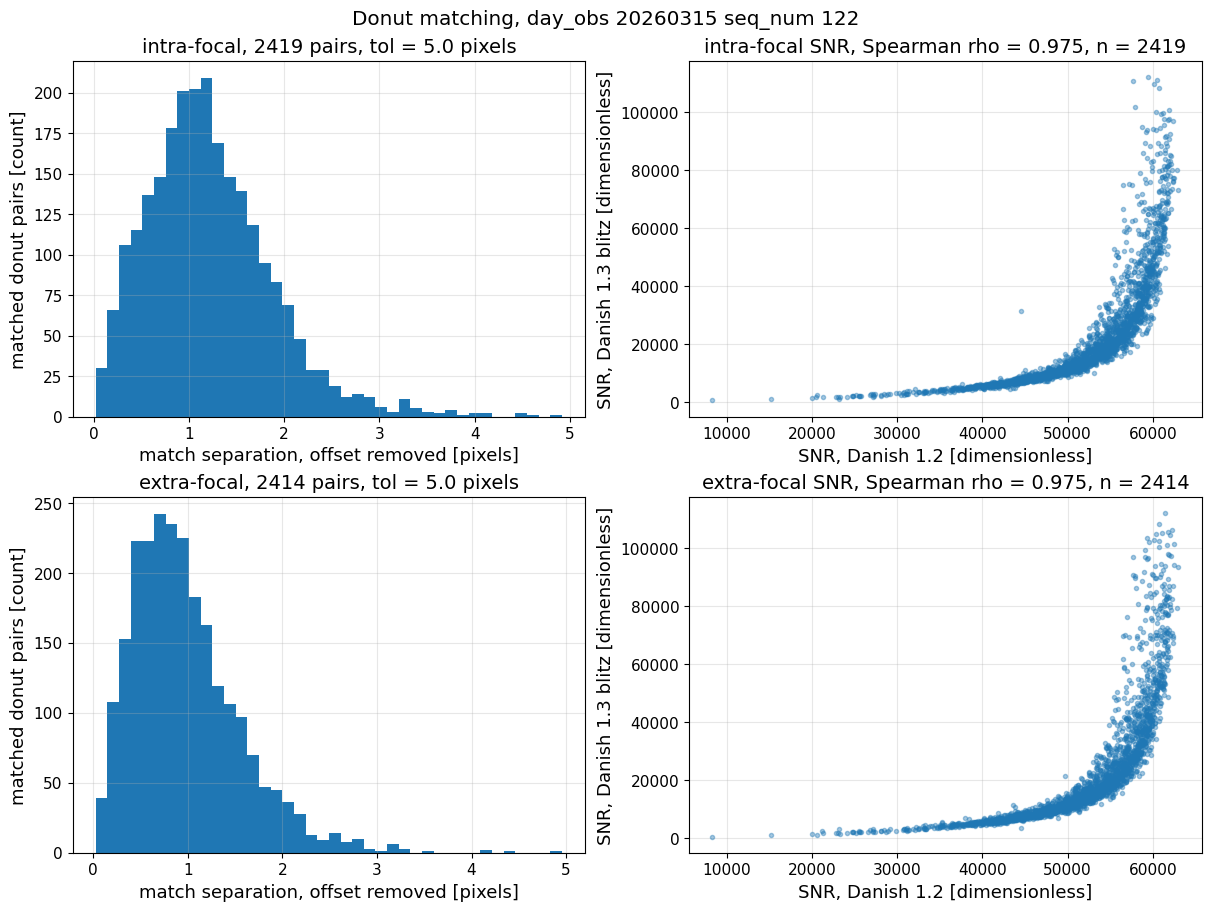

In [17]:
# Signal-to-noise ratio is an independent check that the matched rows are the same
# physical donuts, since the two pipelines measure it separately. The two SNR
# columns are NOT on the same scale -- see the medians below -- so the rank
# correlation is the meaningful statistic and the Pearson r is reported alongside.
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for row, s in enumerate(('intra', 'extra')):
    m = match[s]
    snr_o = np.asarray(old_ok['snr'], dtype=float)[m['idx_old']]
    snr_b = np.asarray(blitz_ok['snr'], dtype=float)[m['idx_blitz']]
    r, rho, n = corr_pair(snr_o, snr_b)
    m['snr_rho'] = rho
    print(f'{s}-focal matched-donut SNR (dimensionless, flux over noise): '
          f'Pearson r = {r:.4f}, Spearman rho = {rho:.4f}, n = {n}')
    print(f'    median SNR, Danish 1.2 = {np.nanmedian(snr_o):9.1f} (dimensionless)')
    print(f'    median SNR, blitz 1.3  = {np.nanmedian(snr_b):9.1f} (dimensionless)')

    axes[row, 0].hist(m['sep_pix'], bins=40)
    axes[row, 0].set_xlabel('match separation, offset removed [pixels]')
    axes[row, 0].set_ylabel('matched donut pairs [count]')
    axes[row, 0].set_title(f'{s}-focal, {len(m["idx_old"])} pairs, '
                           f'tol = {TOL_PIX} pixels')
    axes[row, 1].plot(snr_o, snr_b, 'o', ms=3, alpha=0.4)
    axes[row, 1].set_xlabel('SNR, Danish 1.2 [dimensionless]')
    axes[row, 1].set_ylabel('SNR, Danish 1.3 blitz [dimensionless]')
    axes[row, 1].set_title(f'{s}-focal SNR, Spearman rho = {rho:.3f}, n = {n}')
fig.suptitle(f'Donut matching, day_obs {DAY_OBS} seq_num {SEQ_EXTRA}')
plt.show()

<a id='zernike'></a>
## 8. Zernike Comparison

Both products give micrometres of wavefront in the Optical Coordinate System (OCS), so no
scaling or rotation is applied. The intrinsic wavefront is a batoid model evaluation at the
donut's field position, so it is the tighter test of the field-position and frame
conventions; the deviation is the fitted quantity and carries the estimator's noise.

The blitz is unpaired, so each side of focus is reported separately: pooling them would mix
two measurements of the same star against one Danish 1.2 value.

In [18]:
# Gather the matched Zernikes per side of focus.
zk = {}
for s in ('intra', 'extra'):
    m = match[s]
    zk[s] = dict(
        dev_old=np.asarray(old_ok[f'zk_deviation_{COORD_OLD}'],
                           dtype=float)[m['idx_old']],
        int_old=np.asarray(old_ok[f'zk_intrinsic_{COORD_OLD}'],
                           dtype=float)[m['idx_old']],
        dev_blitz=np.asarray(blitz_ok[f'zk_deviation_{COORD_BLITZ}'],
                             dtype=float)[m['idx_blitz']][:, NOLL],
        int_blitz=np.asarray(blitz_ok[f'zk_intrinsic_{COORD_BLITZ}'],
                             dtype=float)[m['idx_blitz']][:, NOLL])
    print(f'{s}-focal matched Zernike arrays: {zk[s]["dev_old"].shape} '
          f'(Danish 1.2) and {zk[s]["dev_blitz"].shape} (blitz), '
          f'{len(NOLL)} Noll indices')

rows = []
for s in ('intra', 'extra'):
    for c, j in enumerate(NOLL):
        d_dev = zk[s]['dev_blitz'][:, c] - zk[s]['dev_old'][:, c]
        d_int = zk[s]['int_blitz'][:, c] - zk[s]['int_old'][:, c]
        r_dev, rho_dev, n_dev = corr_pair(zk[s]['dev_old'][:, c],
                                          zk[s]['dev_blitz'][:, c])
        rows.append(dict(
            side=s, noll=j, name=NOLL_NAMES.get(j, ''),
            dev_mean_old=np.nanmean(zk[s]['dev_old'][:, c]),
            dev_mean_blitz=np.nanmean(zk[s]['dev_blitz'][:, c]),
            dev_nmad_diff=nmad(d_dev),
            dev_pearson_r=r_dev, dev_spearman_rho=rho_dev,
            int_median_absdiff=np.nanmedian(np.abs(d_int)),
            n=n_dev))
zk_compare = pd.DataFrame(rows)
print('\nDeviation and intrinsic Zernike comparison. Means, nMAD and median |difference| '
      'are in um of wavefront (OCS); r and rho are dimensionless.')
with pd.option_context('display.max_rows', 60, 'display.width', 220,
                       'display.float_format', lambda v: f'{v:9.4f}'):
    display(zk_compare)

intra-focal matched Zernike arrays: (2419, 21) (Danish 1.2) and (2419, 21) (blitz), 21 Noll indices
extra-focal matched Zernike arrays: (2414, 21) (Danish 1.2) and (2414, 21) (blitz), 21 Noll indices

Deviation and intrinsic Zernike comparison. Means, nMAD and median |difference| are in um of wavefront (OCS); r and rho are dimensionless.


,side,noll,name,dev_mean_old,dev_mean_blitz,dev_nmad_diff,dev_pearson_r,dev_spearman_rho,int_median_absdiff,n
0,intra,4,Defocus,-0.4560,-0.5086,0.0522,0.8630,0.8793,0.0014,2419
1,intra,5,Astig45,0.0863,0.0798,0.1424,0.8322,0.8557,0.0003,2419
2,intra,6,Astig0,-0.1911,-0.3295,0.1427,0.5557,0.5974,0.0004,2419
3,intra,7,Coma_y,0.1079,0.2887,0.0810,0.6621,0.7124,0.0001,2419
4,intra,8,Coma_x,0.2389,0.2566,0.0700,0.7210,0.8259,0.0001,2419
5,intra,9,Trefoil_y,0.0311,-0.0171,0.0553,0.8194,0.8263,0.0001,2419
6,intra,10,Trefoil_x,-0.0976,-0.0582,0.0607,0.7982,0.7793,0.0001,2419
7,intra,11,Spherical,0.1905,0.3215,0.0138,0.8337,0.9114,0.0001,2419
8,intra,12,2ndAstig0,-0.1536,-0.1269,0.0371,0.8796,0.8705,0.0000,2419
9,intra,13,2ndAstig45,-0.0256,-0.0342,0.0480,0.8288,0.8358,0.0000,2419


In [19]:
print('Intrinsic wavefront agreement (batoid model at the matched field position).')
print('This is the tight test: it depends only on the field position and the frame, '
      'not on the fit.')
for s in ('intra', 'extra'):
    d_int = zk[s]['int_blitz'] - zk[s]['int_old']
    print(f'  {s:5s}: median |Danish 1.3 - Danish 1.2| over '
          f'{len(zk[s]["int_old"])} donuts and {len(NOLL)} Noll = '
          f'{np.nanmedian(np.abs(d_int)):.3e} um of wavefront')
    print(f'         median |Danish 1.2 intrinsic| for scale = '
          f'{np.nanmedian(np.abs(zk[s]["int_old"])):.4f} um of wavefront')

print('\nDeviation (fitted) agreement, per side of focus:')
for s in ('intra', 'extra'):
    sub = zk_compare[zk_compare.side == s]
    worst = sub.loc[sub.dev_nmad_diff.idxmax()]
    print(f'  {s:5s}: nMAD of the difference spans '
          f'{sub.dev_nmad_diff.min():.4f} to {sub.dev_nmad_diff.max():.4f} '
          f'um of wavefront, largest on Z{int(worst.noll)} {worst["name"]}')
    z4 = sub[sub.noll == 4].iloc[0]
    print(f'         Z4 Defocus deviation: Pearson r = {z4.dev_pearson_r:.4f}, '
          f'Spearman rho = {z4.dev_spearman_rho:.4f}, n = {int(z4.n)}')
    print(f'         median Pearson r over the {len(sub)} Noll = '
          f'{sub.dev_pearson_r.median():.4f} (dimensionless)')

Intrinsic wavefront agreement (batoid model at the matched field position).
This is the tight test: it depends only on the field position and the frame, not on the fit.
  intra: median |Danish 1.3 - Danish 1.2| over 2419 donuts and 21 Noll = 3.875e-05 um of wavefront
         median |Danish 1.2 intrinsic| for scale = 0.0069 um of wavefront
  extra: median |Danish 1.3 - Danish 1.2| over 2414 donuts and 21 Noll = 3.806e-05 um of wavefront
         median |Danish 1.2 intrinsic| for scale = 0.0069 um of wavefront

Deviation (fitted) agreement, per side of focus:
  intra: nMAD of the difference spans 0.0031 to 0.1427 um of wavefront, largest on Z6 Astig0
         Z4 Defocus deviation: Pearson r = 0.8630, Spearman rho = 0.8793, n = 2419
         median Pearson r over the 21 Noll = 0.7367 (dimensionless)
  extra: nMAD of the difference spans 0.0033 to 0.1249 um of wavefront, largest on Z5 Astig45
         Z4 Defocus deviation: Pearson r = 0.8751, Spearman rho = 0.8787, n = 2414
         media

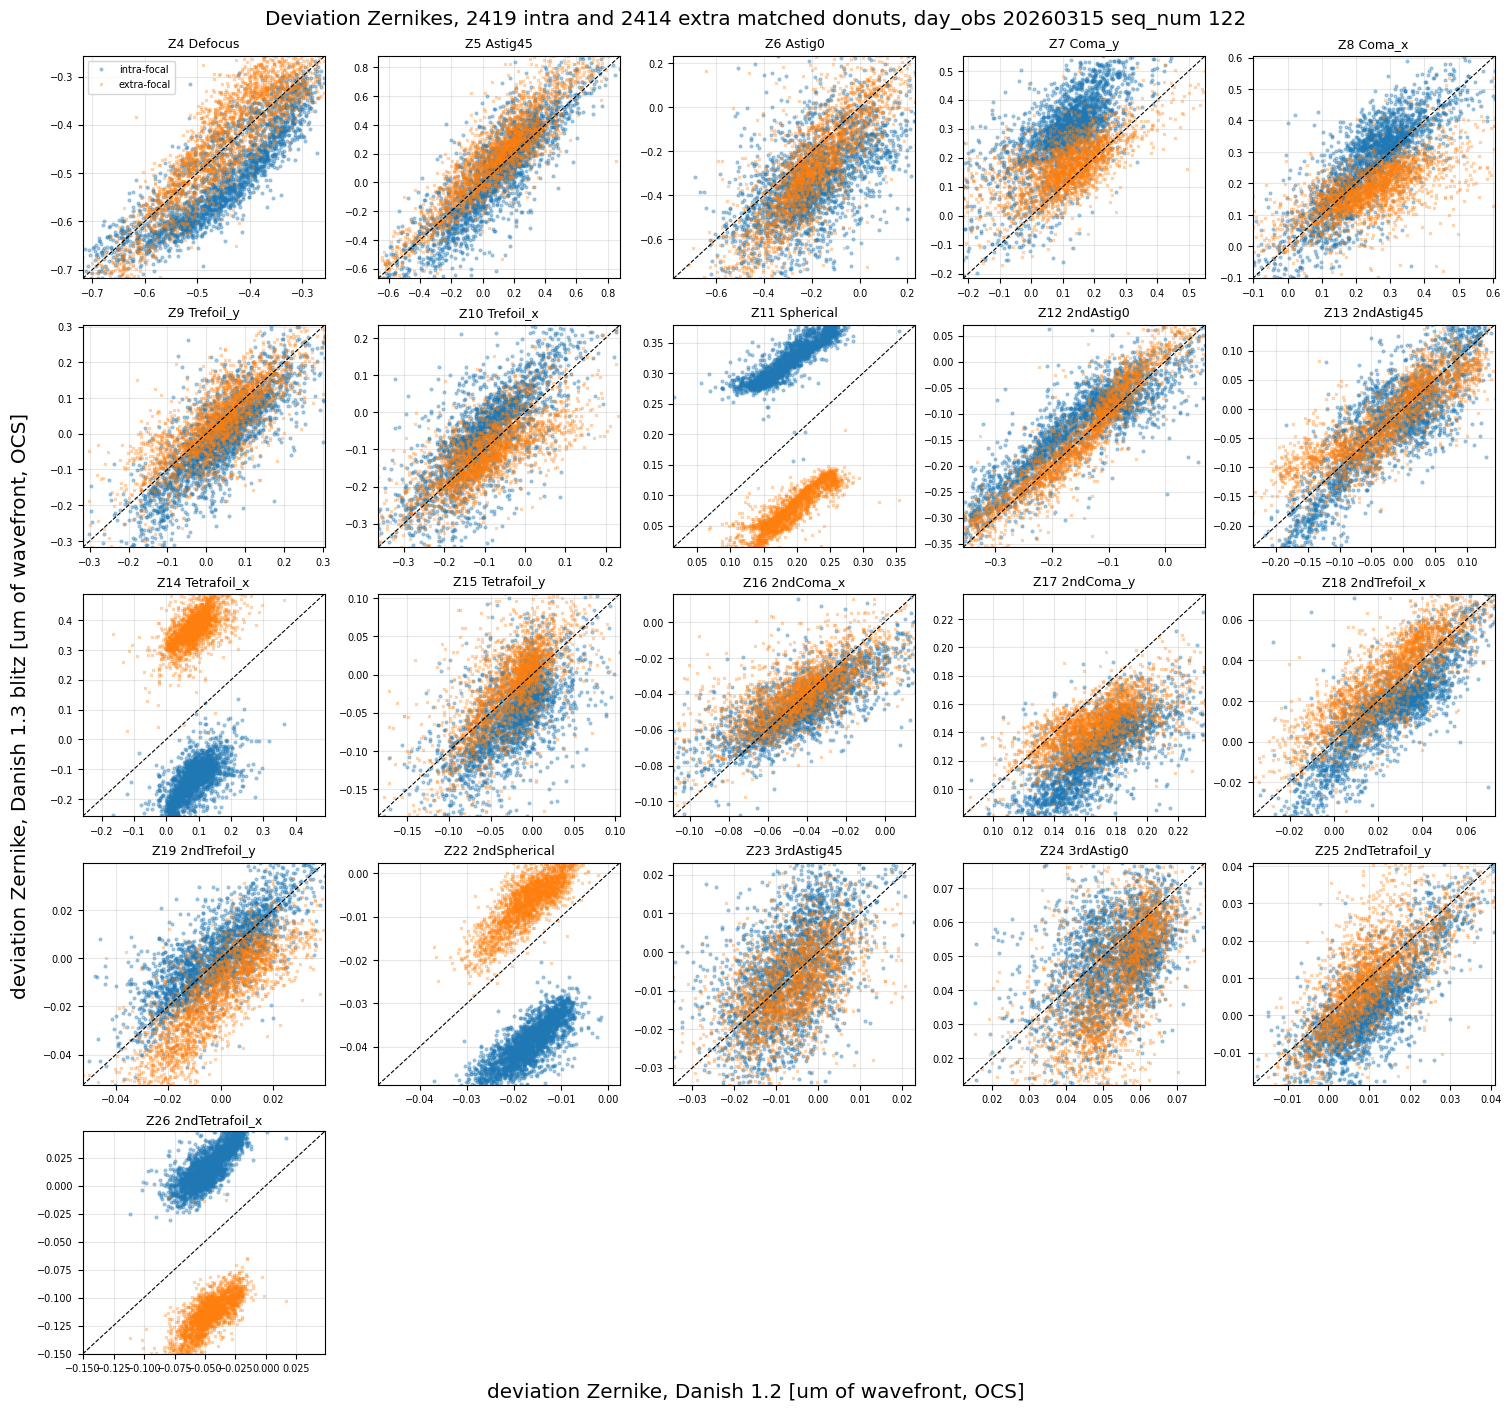

In [20]:
# Per-Noll scatter, blitz against Danish 1.2, both sides of focus overlaid.
ncol = 5
nrow = int(np.ceil(len(NOLL) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(3.0 * ncol, 2.8 * nrow))
for c, j in enumerate(NOLL):
    ax = axes.flat[c]
    vals = []
    for s, mk in (('intra', 'o'), ('extra', 'x')):
        ax.plot(zk[s]['dev_old'][:, c], zk[s]['dev_blitz'][:, c], mk, ms=2,
                alpha=0.35, label=f'{s}-focal')
        vals += [zk[s]['dev_old'][:, c], zk[s]['dev_blitz'][:, c]]
    # Pool both axes and both sides and take the 1st-to-99th percentile RANGE rather
    # than a symmetric limit about zero: several terms carry a real mean offset, and a
    # symmetric frame pushes the cloud into a corner instead of filling the panel.
    both = np.concatenate(vals)
    both = both[np.isfinite(both)]
    if len(both):
        lolim, hilim = np.nanpercentile(both, [1.0, 99.0])
        ax.plot([lolim, hilim], [lolim, hilim], 'k--', lw=0.8)
        ax.set_xlim(lolim, hilim)
        ax.set_ylim(lolim, hilim)
    ax.set_title(zk_label(j), fontsize=9)
    ax.tick_params(labelsize=7)
for ax in axes.flat[len(NOLL):]:
    ax.set_visible(False)
axes.flat[0].legend(fontsize=7)
fig.supxlabel('deviation Zernike, Danish 1.2 [um of wavefront, OCS]')
fig.supylabel('deviation Zernike, Danish 1.3 blitz [um of wavefront, OCS]')
fig.suptitle(f'Deviation Zernikes, '
             f'{len(match["intra"]["idx_old"])} intra and '
             f'{len(match["extra"]["idx_old"])} extra matched donuts, '
             f'day_obs {DAY_OBS} seq_num {SEQ_EXTRA}')
plt.show()

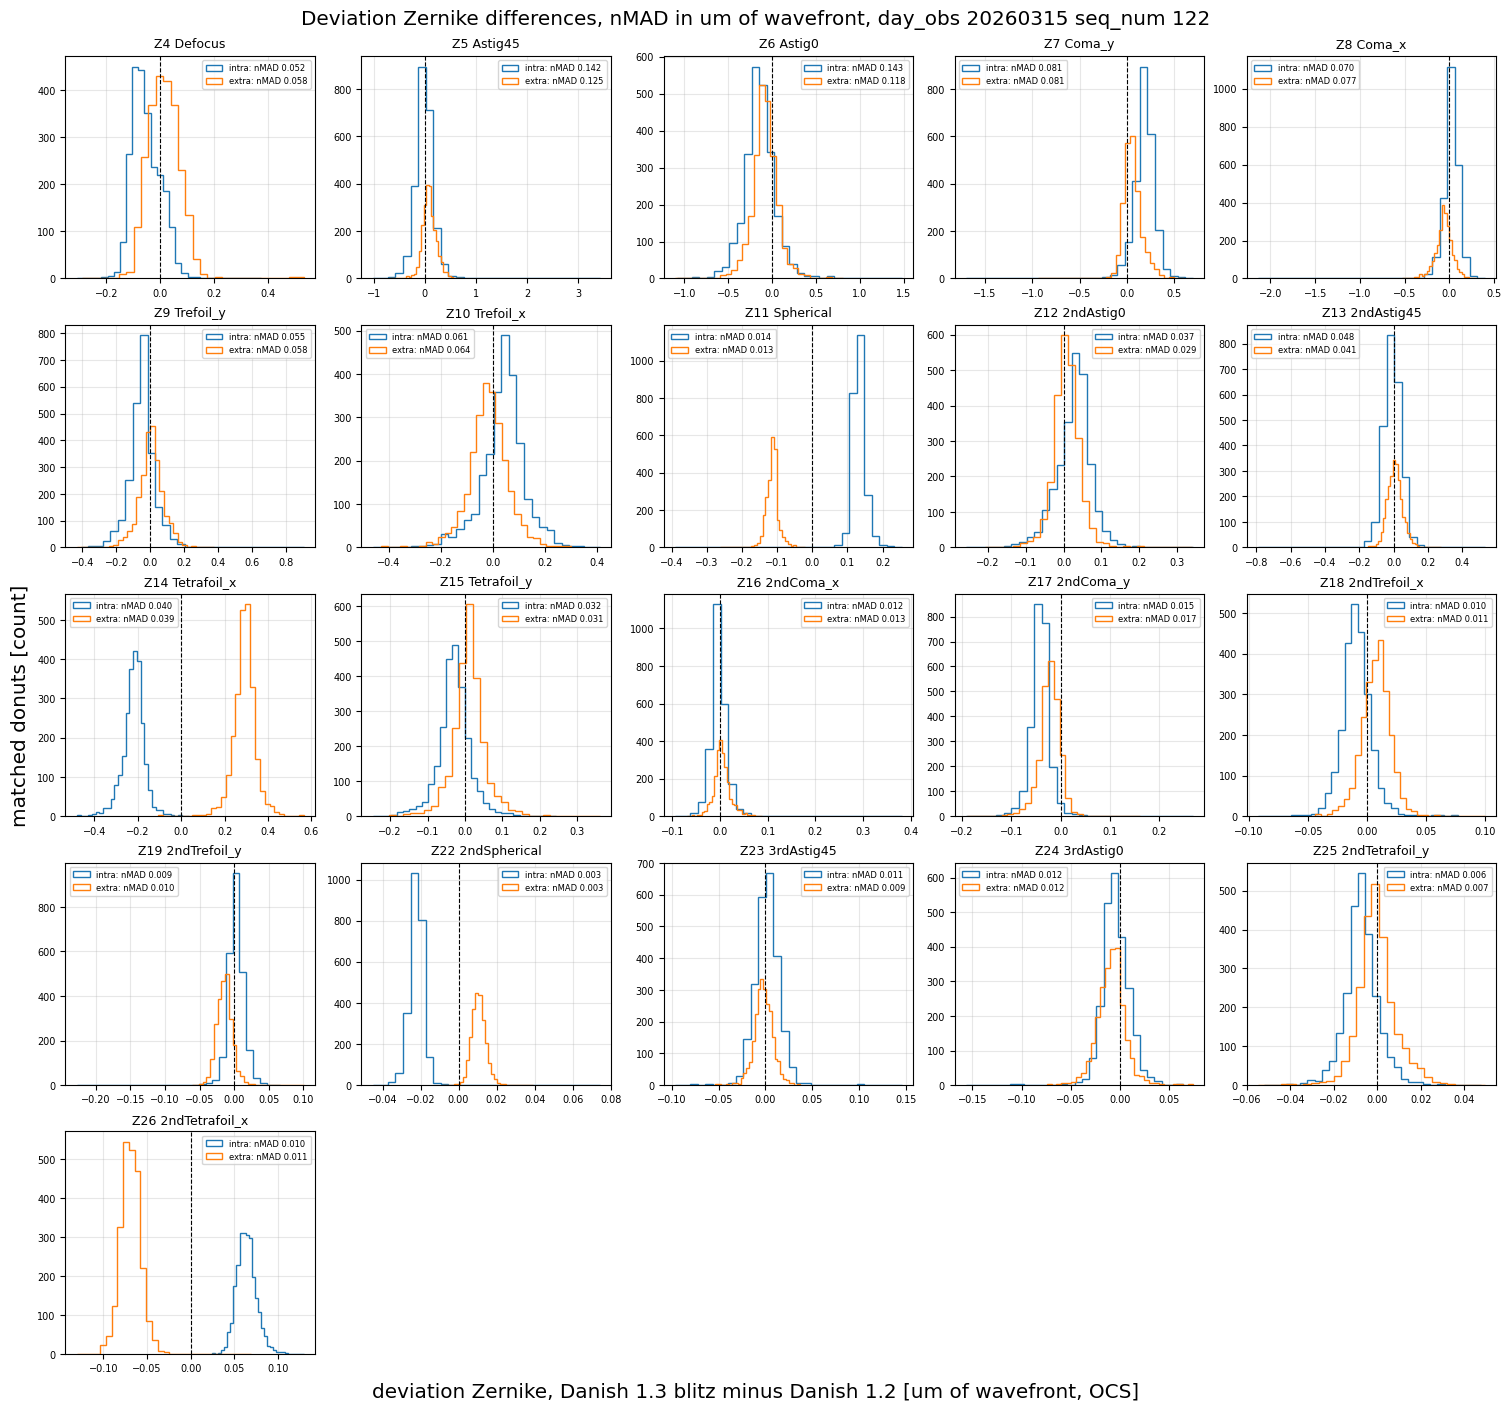

In [21]:
# Per-Noll difference distributions, with the robust scatter annotated.
fig, axes = plt.subplots(nrow, ncol, figsize=(3.0 * ncol, 2.8 * nrow))
for c, j in enumerate(NOLL):
    ax = axes.flat[c]
    for s in ('intra', 'extra'):
        d = zk[s]['dev_blitz'][:, c] - zk[s]['dev_old'][:, c]
        d = d[np.isfinite(d)]
        if len(d):
            ax.hist(d, bins=30, histtype='step',
                    label=f'{s}: nMAD {nmad(d):.3f}')
    ax.axvline(0.0, color='k', ls='--', lw=0.8)
    ax.set_title(zk_label(j), fontsize=9)
    ax.legend(fontsize=6)
    ax.tick_params(labelsize=7)
for ax in axes.flat[len(NOLL):]:
    ax.set_visible(False)
fig.supxlabel('deviation Zernike, Danish 1.3 blitz minus Danish 1.2 '
              '[um of wavefront, OCS]')
fig.supylabel('matched donuts [count]')
fig.suptitle(f'Deviation Zernike differences, nMAD in um of wavefront, '
             f'day_obs {DAY_OBS} seq_num {SEQ_EXTRA}')
plt.show()

<a id='zernike-mean'></a>
### 8.1 The mean of the two unpaired sides against the Danish 1.2 joint fit

Each comparison above pits one unpaired blitz exposure against a Danish 1.2 value that was
fitted jointly from both exposures, so the blitz side carries roughly a factor sqrt(2) more
estimator noise by construction. Averaging the intra- and extra-focal blitz estimates of
the same star is the like-for-like comparison, and is also what a paired blitz reduction
would effectively do.

This uses the stars matched on **both** sides, joined through their common Danish 1.2 row —
the same subset as the blur comparison in section 9.

In [22]:
# Join the two per-side matches through their common Danish 1.2 row, so each star has
# an intra-focal AND an extra-focal blitz estimate against one Danish 1.2 value. This
# subset is reused by the blur comparison in section 9.
oi_i, bi_i = match['intra']['idx_old'], match['intra']['idx_blitz']
oi_e, bi_e = match['extra']['idx_old'], match['extra']['idx_blitz']
common_old = np.intersect1d(oi_i, oi_e)
to_intra = {int(o): int(b) for o, b in zip(oi_i, bi_i)}
to_extra = {int(o): int(b) for o, b in zip(oi_e, bi_e)}
bi_c = np.array([to_intra[int(o)] for o in common_old])
be_c = np.array([to_extra[int(o)] for o in common_old])
print(f'stars matched on BOTH sides of focus: {len(common_old)} '
      f'(of {len(oi_i)} intra and {len(oi_e)} extra matches)')

dev_old_c = np.asarray(old_ok[f'zk_deviation_{COORD_OLD}'],
                       dtype=float)[common_old]
dev_all_b = np.asarray(blitz_ok[f'zk_deviation_{COORD_BLITZ}'], dtype=float)
dev_int_c = dev_all_b[bi_c][:, NOLL]
dev_ext_c = dev_all_b[be_c][:, NOLL]
dev_mean_c = 0.5 * (dev_int_c + dev_ext_c)

rows = []
for c, j in enumerate(NOLL):
    o = dev_old_c[:, c]
    rec = dict(noll=j, name=NOLL_NAMES.get(j, ''), mean_old=np.nanmean(o))
    for tag, v in (('intra', dev_int_c[:, c]), ('extra', dev_ext_c[:, c]),
                   ('mean', dev_mean_c[:, c])):
        r, rho, n = corr_pair(o, v)
        rec[f'r_{tag}'] = r
        rec[f'rho_{tag}'] = rho
        rec[f'nmad_{tag}'] = nmad(v - o)
        rec[f'mean_blitz_{tag}'] = np.nanmean(v)
        if tag == 'mean':
            rec['n'] = n
    rows.append(rec)
dev_mean_compare = pd.DataFrame(rows)

print('\nDeviation Zernike: each blitz side alone, and the mean of the two sides, '
      'against the Danish 1.2 joint fit.')
print('Means and nMAD are in um of wavefront (OCS); r and rho are dimensionless; '
      f'n = {len(common_old)} stars throughout.')
cols = ['noll', 'name', 'mean_old',
        'mean_blitz_intra', 'mean_blitz_extra', 'mean_blitz_mean',
        'r_intra', 'r_extra', 'r_mean',
        'rho_intra', 'rho_extra', 'rho_mean',
        'nmad_intra', 'nmad_extra', 'nmad_mean', 'n']
with pd.option_context('display.max_rows', 30, 'display.width', 250,
                       'display.float_format', lambda v: f'{v:8.4f}'):
    display(dev_mean_compare[cols])

print('Median over the 21 fitted Noll:')
for tag, lbl in (('intra', 'intra only'), ('extra', 'extra only'),
                 ('mean', 'mean of the two sides')):
    print(f'  {lbl:22s}: Pearson r = {dev_mean_compare[f"r_{tag}"].median():.4f}, '
          f'Spearman rho = {dev_mean_compare[f"rho_{tag}"].median():.4f}, '
          f'nMAD of the difference = '
          f'{dev_mean_compare[f"nmad_{tag}"].median():.4f} um of wavefront')
# If the per-side disagreement were independent noise, the mean of the two sides would
# improve the scatter by 1/sqrt(2) = 0.707. Doing better than that means the two sides
# are biased in OPPOSITE directions and cancel on averaging.
print('\nPer-side mean offset from Danish 1.2, and whether the two sides straddle it '
      '[um of wavefront]:')
d_i = dev_mean_compare['mean_blitz_intra'] - dev_mean_compare['mean_old']
d_e = dev_mean_compare['mean_blitz_extra'] - dev_mean_compare['mean_old']
straddle = int(((d_i * d_e) < 0).sum())
print(f'  the two sides fall on opposite sides of the Danish 1.2 mean on '
      f'{straddle} of {len(dev_mean_compare)} Noll terms')
for j in (11, 14):
    row = dev_mean_compare[dev_mean_compare['noll'] == j].iloc[0]
    print(f'  {zk_label(j):18s}: Danish 1.2 {row["mean_old"]:+.4f}, '
          f'blitz intra {row["mean_blitz_intra"]:+.4f}, '
          f'extra {row["mean_blitz_extra"]:+.4f}, '
          f'mean {row["mean_blitz_mean"]:+.4f}')

print(f'\nRatio of the median nMAD, mean of both sides over intra alone = '
      f'{dev_mean_compare["nmad_mean"].median() / dev_mean_compare["nmad_intra"].median():.3f} '
      '(dimensionless). A pure-noise average of two independent estimates would give '
      '0.707.')

stars matched on BOTH sides of focus: 2339 (of 2419 intra and 2414 extra matches)

Deviation Zernike: each blitz side alone, and the mean of the two sides, against the Danish 1.2 joint fit.
Means and nMAD are in um of wavefront (OCS); r and rho are dimensionless; n = 2339 stars throughout.


,noll,name,mean_old,mean_blitz_intra,mean_blitz_extra,mean_blitz_mean,r_intra,r_extra,r_mean,rho_intra,rho_extra,rho_mean,nmad_intra,nmad_extra,nmad_mean,n
0,4,Defocus,-0.4564,-0.5088,-0.4414,-0.4751,0.8633,0.8745,0.9744,0.8796,0.8786,0.9754,0.0521,0.0576,0.0162,2339
1,5,Astig45,0.0852,0.0774,0.1764,0.1269,0.8440,0.9011,0.9659,0.8589,0.8804,0.9675,0.1421,0.1245,0.0543,2339
2,6,Astig0,-0.1912,-0.3280,-0.2771,-0.3025,0.5514,0.7928,0.9013,0.5934,0.8098,0.9116,0.1426,0.1175,0.0581,2339
3,7,Coma_y,0.1072,0.2880,0.1659,0.2270,0.6734,0.6354,0.8032,0.7142,0.6136,0.8293,0.0807,0.0809,0.0541,2339
4,8,Coma_x,0.2381,0.2569,0.1761,0.2165,0.7486,0.6923,0.8598,0.8308,0.6745,0.9101,0.0694,0.0768,0.0449,2339
5,9,Trefoil_y,0.0311,-0.0170,0.0360,0.0095,0.8246,0.7922,0.9656,0.8295,0.7805,0.9636,0.0546,0.0572,0.0223,2339
6,10,Trefoil_x,-0.0974,-0.0575,-0.1148,-0.0861,0.8013,0.7280,0.9558,0.7824,0.7445,0.9484,0.0602,0.0647,0.0283,2339
7,11,Spherical,0.1900,0.3214,0.0757,0.1986,0.8645,0.8865,0.9205,0.9147,0.8988,0.9374,0.0136,0.0125,0.0089,2339
8,12,2ndAstig0,-0.1531,-0.1269,-0.1455,-0.1362,0.8813,0.9402,0.9870,0.8702,0.9513,0.9883,0.0372,0.0291,0.0129,2339
9,13,2ndAstig45,-0.0257,-0.0341,-0.0171,-0.0256,0.8455,0.8384,0.9676,0.8397,0.8703,0.9826,0.0475,0.0412,0.0118,2339


Median over the 21 fitted Noll:
  intra only            : Pearson r = 0.7556, Spearman rho = 0.7824, nMAD of the difference = 0.0321 um of wavefront
  extra only            : Pearson r = 0.7430, Spearman rho = 0.7550, nMAD of the difference = 0.0291 um of wavefront
  mean of the two sides : Pearson r = 0.9082, Spearman rho = 0.9204, nMAD of the difference = 0.0114 um of wavefront

Per-side mean offset from Danish 1.2, and whether the two sides straddle it [um of wavefront]:
  the two sides fall on opposite sides of the Danish 1.2 mean on 15 of 21 Noll terms
  Z11 Spherical     : Danish 1.2 +0.1900, blitz intra +0.3214, extra +0.0757, mean +0.1986
  Z14 Tetrafoil_x   : Danish 1.2 +0.0852, blitz intra -0.1357, extra +0.3764, mean +0.1203

Ratio of the median nMAD, mean of both sides over intra alone = 0.353 (dimensionless). A pure-noise average of two independent estimates would give 0.707.


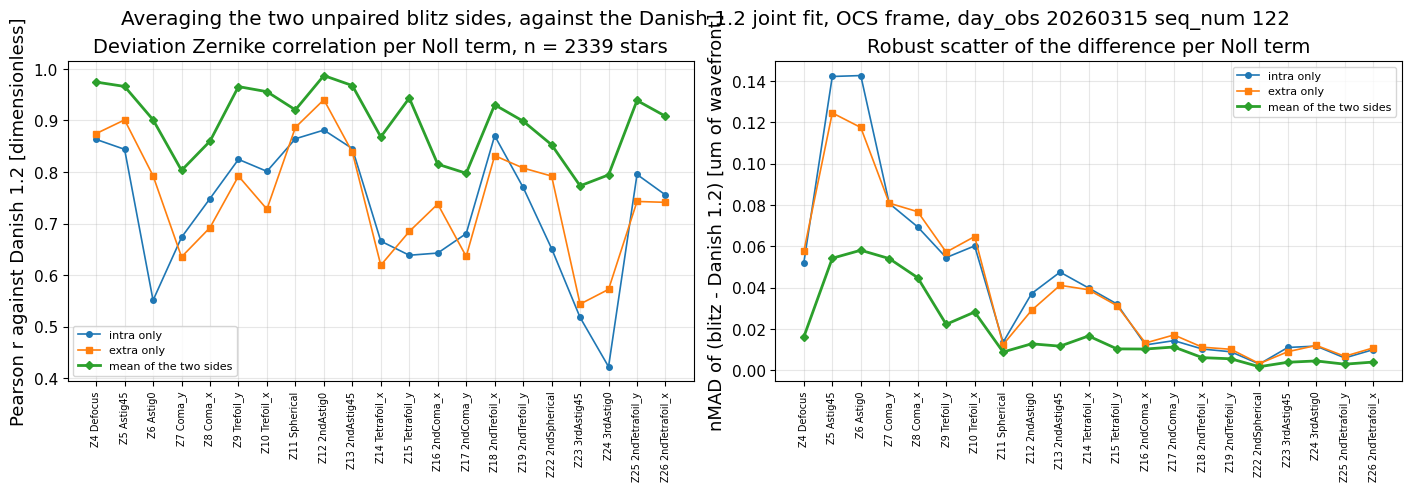

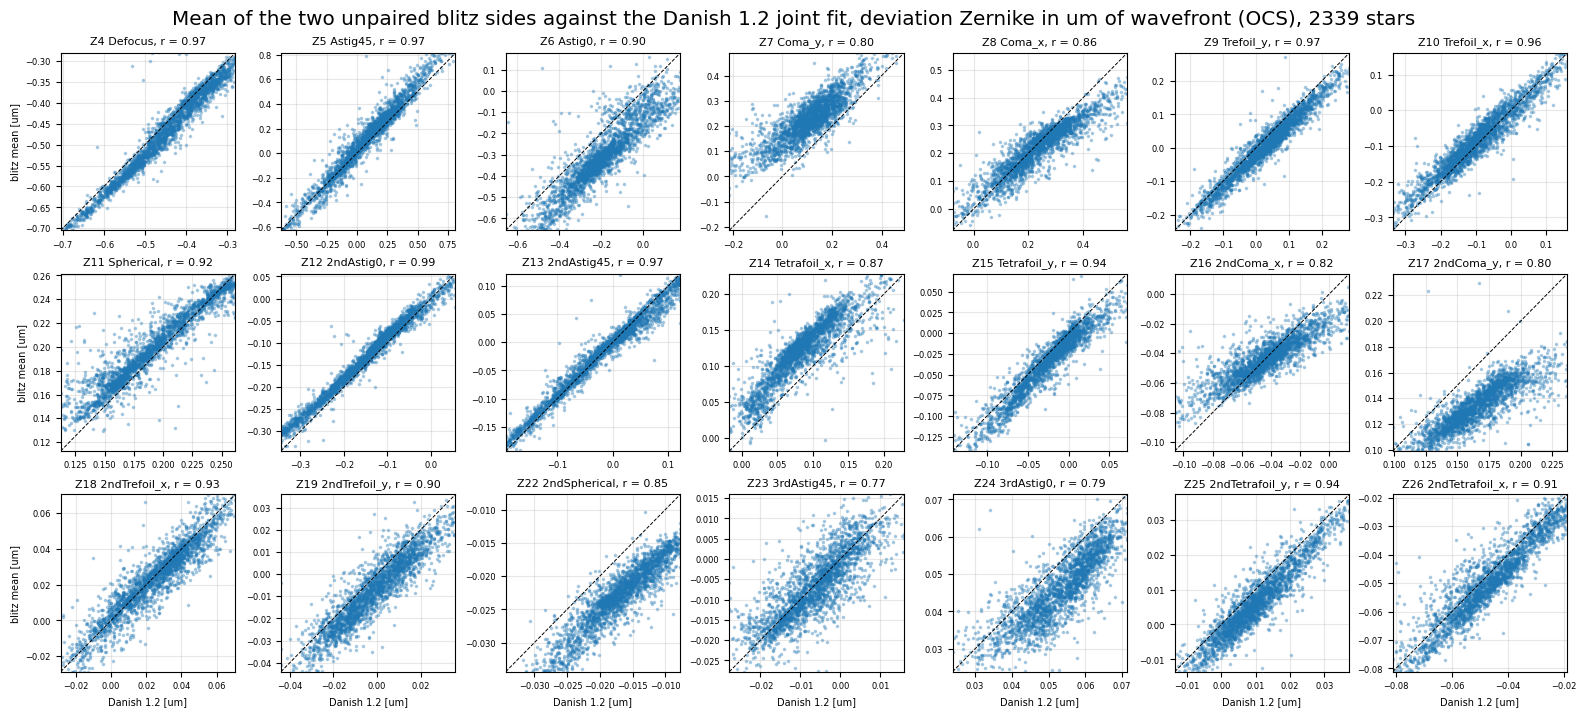

In [23]:
# Left: the correlation against Danish 1.2 per Noll, each side alone and the mean of
# the two. Right: the robust scatter of the difference, same three cases.
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
xs = np.arange(len(NOLL))
for key, mk, lbl, lw in (('intra', 'o-', 'intra only', 1.2),
                         ('extra', 's-', 'extra only', 1.2),
                         ('mean', 'D-', 'mean of the two sides', 2.0)):
    axes[0].plot(xs, dev_mean_compare[f'r_{key}'], mk, ms=4, lw=lw, label=lbl)
    axes[1].plot(xs, dev_mean_compare[f'nmad_{key}'], mk, ms=4, lw=lw, label=lbl)
axes[0].set_ylabel('Pearson r against Danish 1.2 [dimensionless]')
axes[0].set_title(f'Deviation Zernike correlation per Noll term, '
                  f'n = {len(common_old)} stars')
axes[1].set_ylabel('nMAD of (blitz - Danish 1.2) [um of wavefront]')
axes[1].set_title('Robust scatter of the difference per Noll term')
for ax in axes:
    ax.set_xticks(xs)
    ax.set_xticklabels([zk_label(j) for j in NOLL], rotation=90, fontsize=7)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
fig.suptitle(f'Averaging the two unpaired blitz sides, against the Danish 1.2 joint '
             f'fit, {COORD_OLD} frame, day_obs {DAY_OBS} seq_num {SEQ_EXTRA}')
plt.show()

# Per-Noll one-to-one scatter of the mean of the two sides against Danish 1.2.
ncol = 7
nrow = int(np.ceil(len(NOLL) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(2.25 * ncol, 2.35 * nrow))
for c, j in enumerate(NOLL):
    ax = axes.flat[c]
    o = dev_old_c[:, c]
    m = dev_mean_c[:, c]
    good = np.isfinite(o) & np.isfinite(m)
    # Pooled 1st-to-99th percentile RANGE over both axes, not a symmetric limit about
    # zero: several terms carry a real mean offset, so a symmetric frame would push the
    # cloud into a corner rather than showing all the points.
    lolim, hilim = np.nanpercentile(np.concatenate([o[good], m[good]]), [1.0, 99.0])
    ax.plot(o[good], m[good], 'o', ms=1.6, alpha=0.3)
    ax.plot([lolim, hilim], [lolim, hilim], 'k--', lw=0.7)
    ax.set_xlim(lolim, hilim)
    ax.set_ylim(lolim, hilim)
    ax.set_title(f'{zk_label(j)}, r = {dev_mean_compare["r_mean"].iloc[c]:.2f}',
                 fontsize=8)
    ax.tick_params(labelsize=6)
    if c % ncol == 0:
        ax.set_ylabel('blitz mean [um]', fontsize=7)
    if c // ncol == nrow - 1:
        ax.set_xlabel('Danish 1.2 [um]', fontsize=7)
for ax in axes.flat[len(NOLL):]:
    ax.axis('off')
fig.suptitle('Mean of the two unpaired blitz sides against the Danish 1.2 joint fit, '
             f'deviation Zernike in um of wavefront ({COORD_OLD}), '
             f'{len(common_old)} stars')
plt.show()

<a id='blur'></a>
## 9. Donut Blur Comparison

Both products report a per-donut seeing-like width, under different names and from
different fits: Danish 1.2 calls it `blur` (a fitted Gaussian convolution width, in the
`estimatorInfo` diagnostics as `blur_clipped` and `fwhm`) and the blitz calls it
`group_fwhm`. Unlike `snr`, these two are on the same scale in arcsec, so this is a
comparison the matched donuts can actually make.

`group_fwhm` is nominally per fit group rather than per donut, but on this visit every
group holds exactly one donut (`group_size` is 1 on all 6931 fitted rows), so per group
and per donut coincide here. That will not hold once blended donuts are fitted jointly.

Two comparisons, because the two products do not measure the same thing:

1. **Per side of focus.** The blitz is unpaired, so it gives an independent width for the
   intra- and the extra-focal exposure. That the blur differs between the two sides of
   focus is long established and this only confirms it.
2. **The mean of the two sides against the Danish 1.2 value.** The Danish 1.2 `blur` comes
   from a *joint* intra+extra fit, so it has one value per star and its natural blitz
   counterpart is the mean of the two unpaired sides rather than either side alone. This
   needs the stars matched on **both** sides, joined through their common Danish 1.2 row.

intra-focal donut blur, 2419 matched donuts:
    median blur, Danish 1.2      = 0.8995 arcsec (5th to 95th percentile 0.8210 to 1.0687 arcsec)
    median group_fwhm, blitz 1.3 = 0.9355 arcsec (5th to 95th percentile 0.8788 to 1.0474 arcsec)
    median difference (blitz minus Danish 1.2) = +0.0393 arcsec, nMAD = 0.0706 arcsec
    Pearson r = 0.1415, Spearman rho = 0.1456 (dimensionless), n = 2419
extra-focal donut blur, 2414 matched donuts:
    median blur, Danish 1.2      = 0.8994 arcsec (5th to 95th percentile 0.8217 to 1.0660 arcsec)
    median group_fwhm, blitz 1.3 = 0.7294 arcsec (5th to 95th percentile 0.6478 to 0.8029 arcsec)
    median difference (blitz minus Danish 1.2) = -0.1769 arcsec, nMAD = 0.0745 arcsec
    Pearson r = 0.1541, Spearman rho = 0.1916 (dimensionless), n = 2414


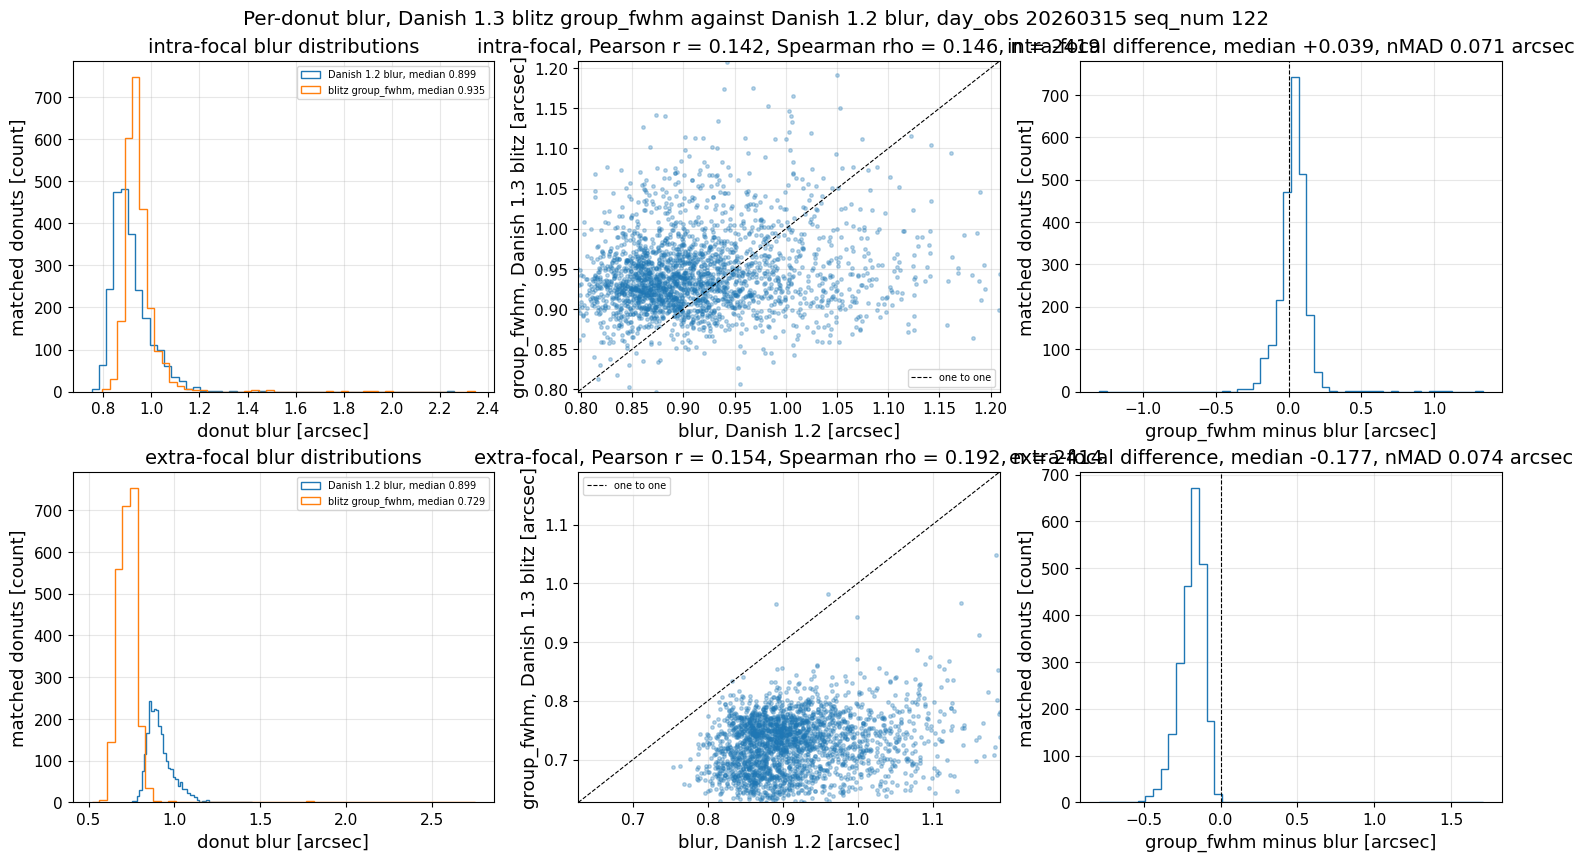


Per-donut blur summary. Medians, differences and nMAD are in arcsec; r and rho are dimensionless.


,side,median_old,median_blitz,median_diff,nmad_diff,pearson_r,spearman_rho,n
0,intra,0.8995,0.9355,0.0393,0.0706,0.1415,0.1456,2419
1,extra,0.8994,0.7294,-0.1769,0.0745,0.1541,0.1916,2414


In [24]:
# Per-donut blur: Danish 1.2 `blur` against the blitz `group_fwhm`, both in arcsec.
# group_fwhm is finite exactly on the group_fit_success rows, so the matched subset
# needs no extra cut.
blur_stats = []
fig, axes = plt.subplots(2, 3, figsize=(15, 8.5))
for row, s in enumerate(('intra', 'extra')):
    m = match[s]
    bl_o = np.asarray(old_ok['blur'], dtype=float)[m['idx_old']]
    fw_b = np.asarray(blitz_ok['group_fwhm'], dtype=float)[m['idx_blitz']]
    d = fw_b - bl_o
    r, rho, n = corr_pair(bl_o, fw_b)
    blur_stats.append(dict(side=s, median_old=np.nanmedian(bl_o),
                           median_blitz=np.nanmedian(fw_b),
                           median_diff=np.nanmedian(d), nmad_diff=nmad(d),
                           pearson_r=r, spearman_rho=rho, n=n))
    print(f'{s}-focal donut blur, {n} matched donuts:')
    print(f'    median blur, Danish 1.2      = {np.nanmedian(bl_o):.4f} arcsec '
          f'(5th to 95th percentile {np.nanpercentile(bl_o, 5):.4f} to '
          f'{np.nanpercentile(bl_o, 95):.4f} arcsec)')
    print(f'    median group_fwhm, blitz 1.3 = {np.nanmedian(fw_b):.4f} arcsec '
          f'(5th to 95th percentile {np.nanpercentile(fw_b, 5):.4f} to '
          f'{np.nanpercentile(fw_b, 95):.4f} arcsec)')
    print(f'    median difference (blitz minus Danish 1.2) = '
          f'{np.nanmedian(d):+.4f} arcsec, nMAD = {nmad(d):.4f} arcsec')
    print(f'    Pearson r = {r:.4f}, Spearman rho = {rho:.4f} (dimensionless), n = {n}')

    # Panel 1: the two distributions.
    axes[row, 0].hist(bl_o[np.isfinite(bl_o)], bins=50, histtype='step',
                      label=f'Danish 1.2 blur, median {np.nanmedian(bl_o):.3f}')
    axes[row, 0].hist(fw_b[np.isfinite(fw_b)], bins=50, histtype='step',
                      label=f'blitz group_fwhm, median {np.nanmedian(fw_b):.3f}')
    axes[row, 0].set_xlabel('donut blur [arcsec]')
    axes[row, 0].set_ylabel('matched donuts [count]')
    axes[row, 0].set_title(f'{s}-focal blur distributions')
    axes[row, 0].legend(fontsize=7)

    # Panel 2: one against the other, with the one-to-one line -- these ARE on the
    # same scale, unlike the two snr columns.
    both = np.concatenate([bl_o, fw_b])
    both = both[np.isfinite(both)]
    lo, hi = np.nanpercentile(both, 0.5), np.nanpercentile(both, 99.5)
    axes[row, 1].plot(bl_o, fw_b, 'o', ms=2.5, alpha=0.3)
    axes[row, 1].plot([lo, hi], [lo, hi], 'k--', lw=0.8, label='one to one')
    axes[row, 1].set_xlim(lo, hi)
    axes[row, 1].set_ylim(lo, hi)
    axes[row, 1].set_xlabel('blur, Danish 1.2 [arcsec]')
    axes[row, 1].set_ylabel('group_fwhm, Danish 1.3 blitz [arcsec]')
    axes[row, 1].set_title(f'{s}-focal, Pearson r = {r:.3f}, '
                           f'Spearman rho = {rho:.3f}, n = {n}')
    axes[row, 1].legend(fontsize=7)

    # Panel 3: the difference.
    dd = d[np.isfinite(d)]
    axes[row, 2].hist(dd, bins=50, histtype='step')
    axes[row, 2].axvline(0.0, color='k', ls='--', lw=0.8)
    axes[row, 2].set_xlabel('group_fwhm minus blur [arcsec]')
    axes[row, 2].set_ylabel('matched donuts [count]')
    axes[row, 2].set_title(f'{s}-focal difference, median '
                           f'{np.nanmedian(dd):+.3f}, nMAD {nmad(dd):.3f} arcsec')
fig.suptitle(f'Per-donut blur, Danish 1.3 blitz group_fwhm against Danish 1.2 blur, '
             f'day_obs {DAY_OBS} seq_num {SEQ_EXTRA}')
plt.show()

blur_compare = pd.DataFrame(blur_stats)
print('\nPer-donut blur summary. Medians, differences and nMAD are in arcsec; '
      'r and rho are dimensionless.')
with pd.option_context('display.width', 200,
                       'display.float_format', lambda v: f'{v:9.4f}'):
    display(blur_compare)

Danish 1.2 rows matched on BOTH sides of focus: 2339

Blitz group_fwhm against the Danish 1.2 joint-fit blur, same stars:
  intra only            : median 0.9356 arcsec, Pearson r = 0.1465, Spearman rho = 0.1437, n = 2339
  extra only            : median 0.7292 arcsec, Pearson r = 0.1542, Spearman rho = 0.1963, n = 2339
  mean of the two sides : median 0.8313 arcsec, Pearson r = 0.2076, Spearman rho = 0.2349, n = 2339
  Danish 1.2 blur       : median 0.8995 arcsec (reference)

intra against extra group_fwhm for the SAME star: Pearson r = 0.0391, Spearman rho = 0.1142, n = 2339


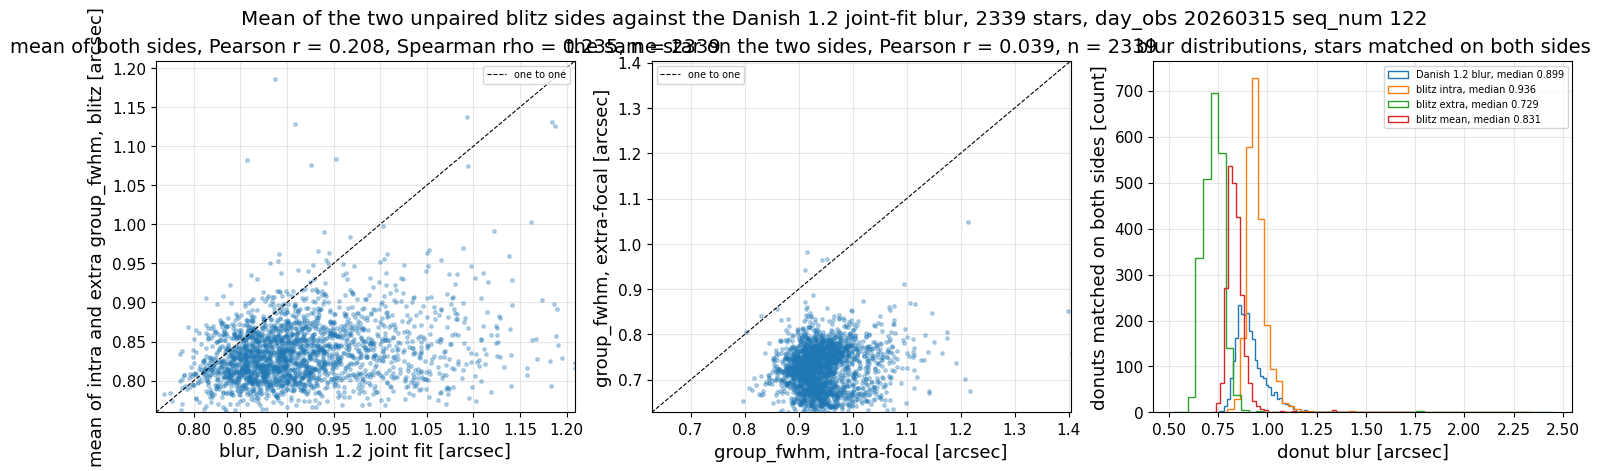


Medians, differences and nMAD are in arcsec; r and rho are dimensionless.


,blitz_quantity,median_blitz,median_diff,nmad_diff,pearson_r,spearman_rho,n
0,intra only,0.9356,0.0397,0.0698,0.1465,0.1437,2339
1,extra only,0.7292,-0.1778,0.0742,0.1542,0.1963,2339
2,mean of the two sides,0.8313,-0.0663,0.0638,0.2076,0.2349,2339


In [25]:
# The Danish 1.2 blur comes from a JOINT intra+extra fit, so its natural blitz
# counterpart is the mean of the two unpaired sides for the same star, not either side
# alone. This reuses the both-sides join built in section 8.1: common_old indexes
# old_ok, and bi_c / be_c index blitz_ok on the intra and extra side respectively.
print(f'Danish 1.2 rows matched on BOTH sides of focus: {len(common_old)}')

fwhm_all = np.asarray(blitz_ok['group_fwhm'], dtype=float)
fw_i = fwhm_all[bi_c]
fw_e = fwhm_all[be_c]
fw_mean = 0.5 * (fw_i + fw_e)
blur_c = np.asarray(old_ok['blur'], dtype=float)[common_old]

print('\nBlitz group_fwhm against the Danish 1.2 joint-fit blur, same stars:')
mean_rows = []
for nm, v in (('intra only', fw_i), ('extra only', fw_e),
              ('mean of the two sides', fw_mean)):
    r, rho, n = corr_pair(v, blur_c)
    d = v - blur_c
    mean_rows.append(dict(blitz_quantity=nm, median_blitz=np.nanmedian(v),
                          median_diff=np.nanmedian(d), nmad_diff=nmad(d),
                          pearson_r=r, spearman_rho=rho, n=n))
    print(f'  {nm:22s}: median {np.nanmedian(v):.4f} arcsec, '
          f'Pearson r = {r:.4f}, Spearman rho = {rho:.4f}, n = {n}')
print(f'  {"Danish 1.2 blur":22s}: median {np.nanmedian(blur_c):.4f} arcsec (reference)')

# Why the mean helps only a little: the two sides of focus do not track each other
# star by star, so there is little common per-star signal to average up.
r_ie, rho_ie, n_ie = corr_pair(fw_i, fw_e)
print(f'\nintra against extra group_fwhm for the SAME star: '
      f'Pearson r = {r_ie:.4f}, Spearman rho = {rho_ie:.4f}, n = {n_ie}')

fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
r_m, rho_m, n_m = corr_pair(fw_mean, blur_c)
both = np.concatenate([blur_c, fw_mean])
both = both[np.isfinite(both)]
lo, hi = np.nanpercentile(both, 0.5), np.nanpercentile(both, 99.5)
axes[0].plot(blur_c, fw_mean, 'o', ms=2.5, alpha=0.3)
axes[0].plot([lo, hi], [lo, hi], 'k--', lw=0.8, label='one to one')
axes[0].set_xlim(lo, hi)
axes[0].set_ylim(lo, hi)
axes[0].set_xlabel('blur, Danish 1.2 joint fit [arcsec]')
axes[0].set_ylabel('mean of intra and extra group_fwhm, blitz [arcsec]')
axes[0].set_title(f'mean of both sides, Pearson r = {r_m:.3f}, '
                  f'Spearman rho = {rho_m:.3f}, n = {n_m}')
axes[0].legend(fontsize=7)

lo2 = np.nanpercentile(np.concatenate([fw_i, fw_e]), 0.5)
hi2 = np.nanpercentile(np.concatenate([fw_i, fw_e]), 99.5)
axes[1].plot(fw_i, fw_e, 'o', ms=2.5, alpha=0.3)
axes[1].plot([lo2, hi2], [lo2, hi2], 'k--', lw=0.8, label='one to one')
axes[1].set_xlim(lo2, hi2)
axes[1].set_ylim(lo2, hi2)
axes[1].set_xlabel('group_fwhm, intra-focal [arcsec]')
axes[1].set_ylabel('group_fwhm, extra-focal [arcsec]')
axes[1].set_title(f'the same star on the two sides, '
                  f'Pearson r = {r_ie:.3f}, n = {n_ie}')
axes[1].legend(fontsize=7)

axes[2].hist(blur_c[np.isfinite(blur_c)], bins=50, histtype='step',
             label=f'Danish 1.2 blur, median {np.nanmedian(blur_c):.3f}')
axes[2].hist(fw_i[np.isfinite(fw_i)], bins=50, histtype='step',
             label=f'blitz intra, median {np.nanmedian(fw_i):.3f}')
axes[2].hist(fw_e[np.isfinite(fw_e)], bins=50, histtype='step',
             label=f'blitz extra, median {np.nanmedian(fw_e):.3f}')
axes[2].hist(fw_mean[np.isfinite(fw_mean)], bins=50, histtype='step',
             label=f'blitz mean, median {np.nanmedian(fw_mean):.3f}')
axes[2].set_xlabel('donut blur [arcsec]')
axes[2].set_ylabel('donuts matched on both sides [count]')
axes[2].set_title('blur distributions, stars matched on both sides')
axes[2].legend(fontsize=7)
fig.suptitle(f'Mean of the two unpaired blitz sides against the Danish 1.2 joint-fit '
             f'blur, {len(common_old)} stars, day_obs {DAY_OBS} seq_num {SEQ_EXTRA}')
plt.show()

blur_mean_compare = pd.DataFrame(mean_rows)
print('\nMedians, differences and nMAD are in arcsec; r and rho are dimensionless.')
with pd.option_context('display.width', 200,
                       'display.float_format', lambda v: f'{v:9.4f}'):
    display(blur_mean_compare)

<a id='corner'></a>
## 10. Corner / In-Focus Product

`donutBlitzResults` on the in-focus (`acq`) member of the triplet covers the corner
wavefront sensors (CWFS). It carries exactly the FAM columns plus three image columns, so
it is the product to read when the donut cutout and the model fit are wanted. No Danish 1.2
counterpart is loaded for the in-focus exposure in this first pass.

In [26]:
cols_fam = set(blitz_fam.colnames)
cols_corner = set(blitz_corner.colnames)
print(f'corner-only columns: {sorted(cols_corner - cols_fam)}')
print(f'FAM-only columns   : {sorted(cols_fam - cols_corner)}')
for c in sorted(cols_corner - cols_fam):
    a = np.asarray(blitz_corner[c])
    print(f'  {c:12s} shape per row = {a.shape[1:]}, dtype = {a.dtype}')

det_corner = np.asarray(blitz_corner['det_name'], dtype=str)
print(f'\ncorner detectors ({len(set(det_corner))}): {sorted(set(det_corner))}')
cand_c = np.asarray(blitz_corner['candidate'], dtype=bool)
fit_c = np.asarray(blitz_corner['group_fit_success'], dtype=bool)
print(f'corner rows: {len(blitz_corner)} total, {int(cand_c.sum())} candidate, '
      f'{int(fit_c.sum())} with group_fit_success')

# The same focus_side helper as the FAM product. This is why it finds the varying
# element instead of assuming one: the two blitz products put the defocal offset in
# DIFFERENT elements of the 3-vector, so a hardcoded index mislabels one of them.
side_c, off_element_c = focus_side(blitz_corner)
off_c = np.asarray(blitz_corner['defocal_offsets'], dtype=float)
print(f'\ncorner defocal_offsets varies in element {off_element_c}, '
      f'while the FAM product varies element {off_element}:')
for row in np.unique(off_c, axis=0):
    print(f'    {row} [m]   count = {int((off_c == row).all(axis=1).sum())} rows')
print(f'corner focus sides: intra {int((side_c == "intra").sum())} rows, '
      f'extra {int((side_c == "extra").sum())} rows')

corner-only columns: ['model_img', 'stamp', 'wf_img']
FAM-only columns   : []
  model_img    shape per row = (83, 83), dtype = float64
  stamp        shape per row = (167, 167), dtype = float64
  wf_img       shape per row = (83, 83), dtype = float64

corner detectors (8): [np.str_('R00_SW0'), np.str_('R00_SW1'), np.str_('R04_SW0'), np.str_('R04_SW1'), np.str_('R40_SW0'), np.str_('R40_SW1'), np.str_('R44_SW0'), np.str_('R44_SW1')]
corner rows: 68 total, 58 candidate, 58 with group_fit_success

corner defocal_offsets varies in element 0, while the FAM product varies element 1:
    [-0.0015  0.      0.    ] [m]   count = 28 rows
    [0.0015 0.     0.    ] [m]   count = 40 rows
corner focus sides: intra 28 rows, extra 40 rows


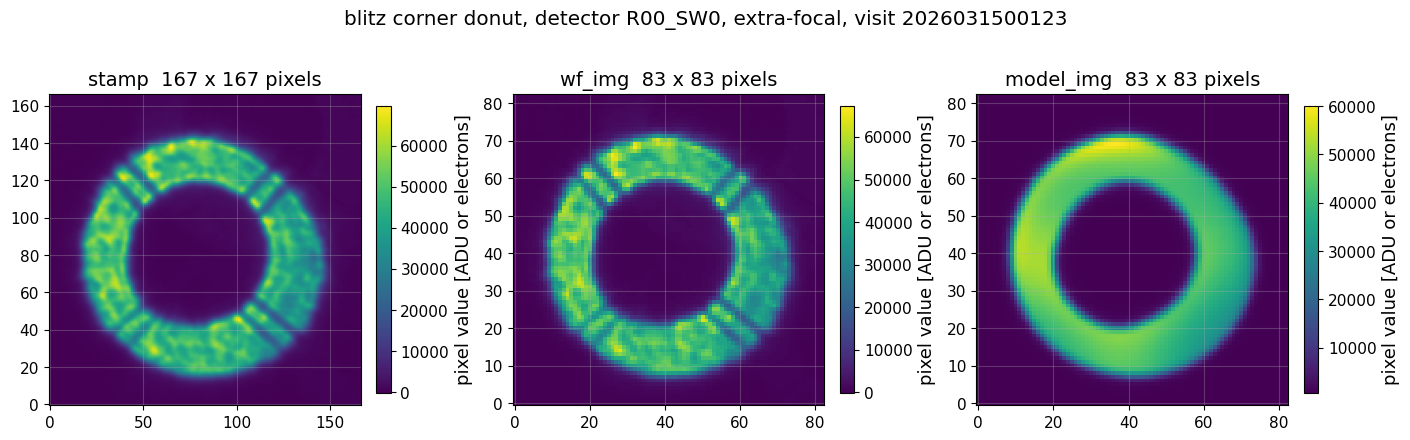

stamp     :  27889 finite of  27889 pixels, range    -146.4376 to   69601.2578, median    1355.2618  [ADU or electrons]
wf_img    :   6889 finite of   6889 pixels, range     -78.9125 to   67245.2969, median    1406.0376  [ADU or electrons]
model_img :   6889 finite of   6889 pixels, range     625.1847 to   60005.2447, median     954.1672  [ADU or electrons]

All three ranges are of order 1e4, consistent with image-plane counts: wf_img holds the donut image and model_img the fitted model, so neither is micrometres of wavefront.


In [27]:
# One fitted corner donut: the stamp, the wf_img and the model image. All three are
# image-plane data in ADU or electrons -- wf_img is NOT a wavefront map despite the
# name, which the ranges below confirm (all three are of order 1e4, far too large for
# micrometres of wavefront). Which of ADU or electrons is not stated by the table.
i_show = int(np.where(fit_c)[0][0])
fig, axes = plt.subplots(1, 3, figsize=(14, 4.6), layout='constrained')
for ax, col in ((axes[0], 'stamp'), (axes[1], 'wf_img'), (axes[2], 'model_img')):
    img = np.asarray(blitz_corner[col][i_show], dtype=float)
    im = ax.imshow(img, origin='lower')
    ax.set_title(f'{col}  {img.shape[0]} x {img.shape[1]} pixels')
    fig.colorbar(im, ax=ax, label='pixel value [ADU or electrons]', fraction=0.046)
fig.suptitle(f'blitz corner donut, detector {det_corner[i_show]}, '
             f'{side_c[i_show]}-focal, visit {VISIT_ACQ}')
plt.show()

for col in ('stamp', 'wf_img', 'model_img'):
    img = np.asarray(blitz_corner[col][i_show], dtype=float)
    print(f'{col:10s}: {int(np.isfinite(img).sum()):6d} finite of {img.size:6d} pixels, '
          f'range {np.nanmin(img):12.4f} to {np.nanmax(img):12.4f}, '
          f'median {np.nanmedian(img):12.4f}  [ADU or electrons]')
print('\nAll three ranges are of order 1e4, consistent with image-plane counts: '
      'wf_img holds the donut image and model_img the fitted model, so neither is '
      'micrometres of wavefront.')

<a id='findings'></a>
## 11. Findings for Josh

Every number below is from the executed cells above, for `day_obs = 20260315`,
`seq_num = 122` (extra-focal FAM key) and `seq_num = 123` (in-focus). Aaron's answers on
the questions this notebook raised are folded in, marked **[AR]**.

### Do the values agree with Danish 1.2?

Yes for the intrinsic; yes for the fitted deviation **once the two unpaired sides are
averaged**, which is the like-for-like comparison against a joint fit; and no for the
per-donut blur, which does not track star by star.

- **Intrinsic wavefront: exact agreement.** Over 2419 intra-focal and 2414 extra-focal
  matched donuts and the 21 fitted Noll, the median
  |Danish 1.3 − Danish 1.2| is **3.9e-05 µm of wavefront** (intra) and
  **3.8e-05 µm of wavefront** (extra), against a median |intrinsic| of
  **0.0069 µm of wavefront**. So the field-position convention, the frame and the units
  all match with no scaling — a ratio of 5.6e-03 (dimensionless, difference over signal).
  **[AR]** `zk_intrinsic` is on the same convention as `zk_deviation`, which this
  agreement confirms rather than assumes.
- **Fitted deviation: only moderate per side, but excellent once the two sides are
  averaged.** Comparing one unpaired blitz exposure against Danish 1.2 gives a median
  Pearson r over the 21 Noll of **0.737** (intra, n = 2419) and **0.743** (extra,
  n = 2414), dimensionless, with the nMAD of the difference spanning 0.0031 to
  0.1427 µm of wavefront (intra, largest on Z6 Astig0) and 0.0033 to 0.1249 µm of
  wavefront (extra, largest on Z5 Astig45). That is not the fair comparison: the Danish
  1.2 value is a **joint** intra+extra fit, so its counterpart is the **mean of the two
  unpaired blitz sides** for the same star. Restricting to the 2339 stars matched on
  **both** sides, so that all three columns below are the same stars:

  | quantity, median over the 21 fitted Noll | intra only | extra only | mean of both sides |
  |---|---|---|---|
  | Pearson r against Danish 1.2 [dimensionless] | 0.7556 | 0.7430 | **0.9082** |
  | Spearman rho against Danish 1.2 [dimensionless] | 0.7824 | 0.7550 | **0.9204** |
  | nMAD of (blitz − Danish 1.2) [µm of wavefront] | 0.0321 | 0.0291 | **0.0114** |

  Z4 Defocus goes from Pearson r = 0.8633 (intra) and 0.8745 (extra) to **0.9744** for the
  mean, with the nMAD of the difference falling from 0.0521 and 0.0576 to
  **0.0162 µm of wavefront**. The terms that were worst per side improve most: Z6 Astig0
  from Pearson r = 0.5514 (intra) to **0.9013**, Z24 3rdAstig0 from 0.4226 to **0.7945**.
  So the two reductions do agree on the fitted deviation; the per-side comparison was
  understating it.

- **The per-side disagreement is anti-correlated between the two sides, not independent
  noise.** The ratio of the median nMAD, mean-of-both-sides over intra-alone, is
  **0.353 (dimensionless)**. Averaging two estimates carrying *independent* noise would
  give 0.707, so falling well below that means the intra and extra unpaired estimates sit
  on **opposite sides** of the Danish 1.2 value and cancel when averaged. In other words a
  single unpaired exposure carries a side-dependent bias of opposite sign on the two
  sides, which a joint fit does not have. **Z11 Spherical** and **Z14 Tetrafoil_x** are the
  clearest cases, on the 2339-star subset, in µm of wavefront:

  | term | Danish 1.2 | blitz intra | blitz extra | blitz mean of both |
  |---|---|---|---|---|
  | Z11 Spherical | 0.1900 | 0.3214 | 0.0757 | **0.1986** |
  | Z14 Tetrafoil_x | 0.0852 | −0.1357 | 0.3764 | **0.1203** |

  The two sides fall on **opposite sides** of the Danish 1.2 mean on 15 of the 21
  Noll terms, and on Z11 and Z14 the mean of the two lands far closer than either side
  alone. Those are the
  same two terms as the unexplained Z11/Z14 intra- versus extra-focal split already seen in
  the unpaired Danish corner-wavefront-sensor (CWFS) output, where the reported values were
  also of opposite sign on the two sides. That split is an **open question**, so this is
  offered as the same structure appearing in FAM, not as an explanation of either.
  **This is one of the two substantive questions on the values**, and it matters for any
  use of a single unpaired exposure on its own.

- **Per-Noll mean offsets survive the averaging**, so they are a genuine difference between
  the two reductions rather than per-star noise: Z7 Coma_y means **0.1072** (Danish 1.2)
  against **0.2270** (blitz, mean of both sides) and Z6 Astig0 **−0.1912** against
  **−0.3025**, both in µm of wavefront, against an nMAD of the difference of 0.0541 and
  0.0581 µm of wavefront respectively. Z7/Z16/Z17 (the coma-like terms, Pearson r = 0.80,
  0.82, 0.80 for the mean) and Z23 3rdAstig45 (0.7732) are the weakest terms after
  averaging and are where to look.

  **[AR]** These offsets are very likely the result of the change from paired to unpaired
  fitting, not a convention error. Pairing two donuts that differ as much as these do — in
  `group_fwhm` and in Z11, as the straddling above shows — produces a bias in the joint
  solution; unpairing undoes that bias and so yields somewhat different results. On this
  reading the Z6/Z7 offsets are the expected consequence of removing the pairing rather than
  an anomaly, and the anti-correlation ratio of 0.353 (dimensionless) above is the same
  effect seen from the other direction. What these tables cannot separate is the pairing
  change from the code-version change (ts_wep 16.6.0, danish 1.2.1) that the blitz collection
  carries at the same time; blitz run in paired mode on the same visits would isolate the
  two.
- **Per-donut blur: the distributions overlap but the per-star values do not correlate.**
  This is the second substantive question. The medians are the same order — Danish 1.2
  `blur` **0.899 arcsec** against blitz `group_fwhm` **0.936 arcsec** (intra) and
  **0.729 arcsec** (extra) — and the ~0.21 arcsec difference between the two blitz sides
  is expected: that the blur differs on either side of focus is long established, so this
  only confirms it. What does not work is the **per-star** correspondence:
  - Per side, Pearson r = **0.147** / Spearman rho = **0.144** (intra) and **0.154** /
    **0.196** (extra), dimensionless, n = 2339 stars matched on both sides.
  - Because the Danish 1.2 value is a single joint intra+extra fit, its proper counterpart
    is the **mean of the two blitz sides**. That mean does correlate better —
    Pearson r = **0.208**, Spearman rho = **0.235**, n = 2339, median
    **0.831 arcsec**, i.e. **−0.066 arcsec** against the Danish 1.2 blur — but it is still
    weak.
  - The reason the mean helps so little: the intra and extra `group_fwhm` **for the same
    star** are essentially uncorrelated, Pearson r = **0.039** (Spearman rho = **0.196**,
    n = 2339). Averaging two values cannot recover a per-star signal that is absent from
    both.
  - **The contrast with the Zernikes is the diagnostic.** On the same 2339 stars, averaging
    the two sides takes the deviation Zernikes from a median Pearson r of 0.756 to
    **0.908** and cuts the nMAD of the difference to **0.353** of its per-side value
    (dimensionless), i.e. better than the 0.707 independent-noise expectation. Averaging
    the blur moves Pearson r only from 0.147 to **0.208**. So the two unpaired exposures
    *do* carry a consistent shared measurement of the wavefront — the machinery works —
    but they do not carry a consistent shared measurement of the donut width. That points
    at `group_fwhm` specifically: either it is dominated by fit noise rather than by the
    star's actual width, or it is not the same quantity as Danish 1.2's `blur`. Worth a
    look from your side.

### Requests on the format

**Metadata: already there, and it already covers the requests — but it is hidden by
default.** *(Corrected: an earlier version of this notebook reported the blitz metadata as
empty. It is not — the Butler formatter strips astropy metadata unless asked not to.)* The
tables must be read as

```python
butler.get('donutBlitzFamResults', collections=..., instrument='LSSTCam',
           visit=..., parameters={'strip_astropy_meta_yaml': False})
```

A plain `butler.get` returns `.meta` with **0 keys**; with the parameter it returns
**4232** on the FAM product and **359** on the corner product, which split as **39
science/config keys** (identical in both products), a per-detector-exposure `det_meta`
dict (378 and 8 entries), and the `LSST.BUTLER.*` input provenance (4192 and 319 keys).
**The one request here is to make this the default, or to document the parameter**, since a
reader who does not know it concludes the metadata is missing.

Everything section 11 would otherwise have asked for is already present:

| asked for | metadata key | value on this visit |
|---|---|---|
| camera rotator angle for OCS vs CCS | `rot_tel_pos` | 0.17660918 deg |
| " | `boresight_rot_angle`, `boresight_par_angle` | 11.24885987 deg, 101.42546904 deg |
| `nollIndices` stated, not inferred | `noll_indices` | [4–19, 22–26], 21 terms |
| side of focus, paired vs unpaired | `mode`, `wf_mode`, `intra_visit_id`, `extra_visit_id` | 'fam', 'unpaired', 2026031500121, 2026031500122 |
| the binning behind the centroid offset | `binning`, `stamp_frame`, `stamp_size` | 2, 'CCS', 167 pixels |
| Zernike vector lengths | `zk_deviation_jmax`, `zk_intrinsic_jmax` | 26, 66 |

Three further things the metadata does better than Danish 1.2, worth keeping:

1. **Units are attached.** The blitz angles are `astropy.Quantity` in deg. The Danish 1.2
   `meta` stores **bare floats in radians with no unit** — `rotTelPos` reads 0.00308
   against the blitz 0.17661 deg, which looks like a disagreement until the radians are
   converted. Converted, the two products agree on `rot_tel_pos`/`rotTelPos`,
   `boresight_rot_angle`/`rotAngle` and `boresight_par_angle`/`parallacticAngle` to
   **~1e-13 deg**. The new behaviour is the right one.
2. **`notes` documents the metadata in the table.** It states, among others, that
   `rot_tel_pos` is derived as `(boresight_par_angle − boresight_rot_angle − 90 deg)`
   wrapped to (−180, 180] and is "not either raw input" — this notebook verifies that
   formula reproduces the stored value to **1.3e-14 deg** — that `date` is mid-exposure,
   and that `*_elapsed` is CPU time in FAM mode but wall clock in corner mode. More
   formats should do this.
3. **Version and configuration provenance is complete**: `ts_wep_version`,
   `danish_version`, `batoid_version`, plus `obscuration` = 0.612 (dimensionless),
   `max_donuts`, `max_nearby` and the four background-annulus fractions.

**The input provenance names the intrinsic calibration.** Rolling up the
`LSST.BUTLER.INPUT.<n>.DATASETTYPE` / `.RUN` keys by dataset type shows both products took
`intrinsicZernikes` from
**`LSSTCam/calib/DM-55048/intrinsicZernikes.v1.0/intrinsicsGen.20260528a`** (189
detector-exposures in FAM, 8 in corner), alongside `raw`, `ptc`, `flat`, `linearizer`,
`crosstalk` and the `the_monster_20250219` refcat. No request here — this is already the
right design, and it is the one piece of metadata that Danish 1.2 has no equivalent of at
all: the Danish 1.2 table carries **12 metadata keys and no provenance block**, so the
calibrations behind it cannot be recovered from the table. Note that this does *not* by
itself explain the exact intrinsic agreement found in section 8 — it establishes only that
the two **blitz** products share the intrinsic calibration; whether Danish 1.2 used this
same `intrinsicZernikes` run would have to be checked against its own collection, which the
table cannot answer.

One detail the roll-up surfaces that may or may not be intended: within this single visit,
`ptc`, `flat` and `linearizer` are each drawn from **two different run collections** (a
`DM-53619`/`DM-50162` pair and a `DM-53722` pair), while `crosstalk` and
`intrinsicZernikes` come from one each. If the 189 detector-exposures are meant to share
one calibration version, that is worth a look; if the split is by detector generation it is
expected, but nothing in the metadata says which.

**`defocal_offsets` needs its axes documented.** The 3-vector says which of
**(focal-plane height, camera hexapod dz, M2 hexapod dz)** has been offset **[AR]** — and
that information is needed downstream in computing both the intrinsic TA and the pupil
mask, so it must be unambiguous. **This is the one request the metadata does not already
answer** — no key among the 39 mentions `defocal` or `offset`, and `notes` does not cover
it either. Two things make it ambiguous now: the element order is not stated anywhere in
the table or its metadata, and the two products **use different elements** —
`donutBlitzFamResults` varies **element 1** (`[0, ±0.0015, 0]` m) while `donutBlitzResults`
varies **element 0** (`[±0.0015, 0, 0]` m). A reader that hardcodes an index silently
mislabels the side of focus in one of the two. A column naming the offset axis, or a
documented fixed order, resolves it.

**`wf_img` should say ADU or electrons.** On the corner product `wf_img` is 83×83 pixels
with a range of **−78.9 to 67245** and a median of **1406** — the same order as `stamp`
(−146 to 69601) and `model_img` (625 to 60005). **[AR]** These are image-plane data: the
donut image and the fitted model, in either ADU or electrons. The name `wf_img` reads as a
wavefront map, which it is not; which of ADU or electrons applies is worth stating.

**`snr` is not the same quantity in the two products.** On matched donuts the medians are
**52850 (Danish 1.2)** against **15838 (blitz)**, dimensionless, so the columns differ by
roughly a factor 3.3 and are not interchangeable. The rank correlation is excellent
(Spearman rho = 0.975, n = 2419), which is what confirms the match, but the Pearson r is
only 0.737 because the relation is not linear. A note on the definition, or a distinct
column name, would prevent a silent misuse.

**Centroid positions carry a constant few-pixel offset relative to Danish 1.2.** Matching
per CCD needs a shift of **(dx, dy) = (−3.35, −3.98) pixels** on the intra-focal side and
**(−3.06, −3.80) pixels** on the extra-focal side (blitz `x_det`/`y_det` minus the
Danish 1.2 `centroid_*`). With the shift removed the median separation is
**1.138 pixels** (intra) and **0.885 pixels** (extra); without it the match is dominated
by accidental neighbours. This looks like a pixel-origin or a binning convention
difference (the Danish 1.2 collection is `bin_x2`) and is worth pinning down explicitly.

**Unpaired output needs an explicit focus-side column.** The side of focus is recoverable
only from the sign of whichever `defocal_offsets` element happens to vary — the same
problem as above, from the other direction.

**Only 3 of 58 blitz column names are shared with the Danish 1.2 table** — `coord_ra`,
`coord_dec` and `snr` — and `snr` is not the same quantity despite the name. So this is a
new schema rather than an extension, and every downstream reader has to be rewritten
rather than adapted. That is acceptable, but it is worth knowing it is the situation.

**Missing relative to Danish 1.2**, for work that currently depends on them:
- No total `zk`, only the `zk_deviation` and `zk_intrinsic` split. Danish 1.2 carries all
  three, and `zk − zk_intrinsic − zk_deviation` is a useful self-check.
- No per-donut fit-quality scalar comparable to `chi2`. The blitz `group_fit_cost` and
  `group_fit_optimality` are per group, not per donut. (`group_fwhm` is the nominal `blur`
  counterpart, but see the blur finding above — it does not track per star.)
- **Not missed:** the North/West sky-frame Zernikes (`zk_NW`) and sky-frame field angles
  (`th_N`, `th_W`). **[AR]** `NW` was never really used, so dropping it is fine.

### Things the notebook resolved, so they are not questions

- **`zk_intrinsic` is on the same convention as `zk_deviation`** **[AR]**, so the 67-long
  intrinsic is Noll 4 through 66 on the same 0-indexed basis as the 27-long deviation. The
  `zk_deviation_jmax` = 26 and `zk_intrinsic_jmax` = 66 metadata keys state both lengths.
- **The fitted Noll set no longer has to be inferred.** `noll_indices` in the metadata is
  [4–19, 22–26], identical to what this notebook inferred from the column contents and to
  the Danish 1.2 `nollIndices`. Within the arrays the not-fitted entries still use two
  different encodings — identically zero at Noll 0–3, all-NaN at Noll 20 and 21 — which is
  worth a one-line note but is no longer ambiguous now that `noll_indices` is read.
- **The blur differing between the two sides of focus is expected**, not a new finding —
  it has been known for a long time. Only the absent per-star correlation is new.
- **The `eb` frame is still undocumented.** `zk_deviation_eb` and `zk_intrinsic_eb` sit
  alongside the CCS and OCS pair with no definition. **[AR]** Not known on this side
  either — worth a one-line definition, but nothing here depends on it.
- **`group_fit_success` is a clean selection flag.** It is True on 6931 of 7652 rows and is
  exactly the set with a finite deviation vector on all 21 fitted Noll — zero rows
  disagree in either direction. `candidate` is True on 6933 and `group_size` is
  `{0: 719, 1: 6933}`, so `group_fit_outcome = 'exception'` accounts for the 2-row gap.
  `group_fwhm` is finite on exactly the same 6931 rows.
- **`rejected_*` flags ARE populated on this visit**: `rejected_sat` 684,
  `rejected_outer_frac` 148, `rejected_inner_frac` 75, `rejected_snr` 41 rows. An earlier
  look at a different visit (`seq_num = 73`) found none set, so that was visit-dependent
  rather than a blanket bug.
- **`donut_id` cannot be used to match.** Danish 1.2 uses a positional string
  (`2026031500122_001_000`), the blitz a Gaia source id; the intersection is 0 of 3414 and
  3920 unique values.
- **Detector coverage is almost identical**: 181 detectors in the blitz against 180 in
  Danish 1.2, the extra one being `R30_S12`.
- **Fit groups are all singletons on this visit** (`group_size` is 1 on every fitted row),
  so every `group_*` column is effectively per donut here. That will change once blended
  donuts are fitted jointly, and any reader should not assume it.